# **FINM 33100 Project - Track 1: Market Structure**

## How diversified are traditional portfolio construction methods?

### By: Chirag Jha, Anthony Mazy, Bangjie Xu, and Enrique Zambrano

#### Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import ScalarFormatter
import plotnine as p9
import cvxpy as cp
import pickle
from pathlib import Path
from IPython.display import display
import os
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

import functions.pca_functions as pca_functions
import functions.portfolio_functions as port_functions
import functions.diversification_functions as div_functions


In [5]:
PROJECT_ROOT = Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "olhcv_merged.parquet"
CCM_LINKTABLE_PATH = PROJECT_ROOT / "data" / "ccm_linktable.csv"


for required_path in (DATA_PATH, CCM_LINKTABLE_PATH):
    if not required_path.exists():
        raise FileNotFoundError(f"Data file not found: {required_path}")

# **1. Data**

## 1.1. Data preparation

The dataset is loaded from the project data directory. We use `permno` as the permanent security identifier, `date` as the trading date, `ret` as the daily return, and `mcap` as market capitalization.

In [6]:

def format_market_data_for_display(data_frame):
    display_frame = data_frame.copy()
    if "ret" in display_frame.columns:
        display_frame["ret"] = display_frame["ret"] * 100
    if "mcap" in display_frame.columns:
        display_frame["mcap"] = display_frame["mcap"] / 1_000_000
    return display_frame.rename(columns={"ret": "ret (%)", "mcap": "mcap ($ millions)"})

stock_panel = pd.read_parquet(DATA_PATH)
stock_panel["date"] = pd.to_datetime(stock_panel["date"], errors="coerce").astype("datetime64[ns]")
stock_panel["permno"] = pd.to_numeric(stock_panel["permno"], errors="coerce").astype("Int64")
stock_panel = stock_panel.sort_values(["permno", "date"]).reset_index(drop=True)
stock_panel["stock_name"] = stock_panel["ticker"].astype("string")

# Match each CRSP security to the CCM company name in force on its observation date.
ccm_links = pd.read_csv(CCM_LINKTABLE_PATH, dtype={"LPERMNO": "Int64"})
ccm_links["link_start"] = pd.to_datetime(ccm_links["LINKDT"], errors="coerce").astype("datetime64[ns]")
ccm_links["link_end"] = pd.to_datetime(ccm_links["LINKENDDT"], errors="coerce").astype("datetime64[ns]")
ccm_links["link_end"] = ccm_links["link_end"].fillna(pd.Timestamp.max)
ccm_links = ccm_links.loc[
    ccm_links["LPERMNO"].notna()
    & ccm_links["conm"].notna()
    & ccm_links["link_start"].notna()
    & ccm_links["LINKPRIM"].isin(["P", "C"])
].copy()
ccm_links = ccm_links.rename(columns={"LPERMNO": "permno", "conm": "company_name"})

# merge_asof requires the merge key to be globally sorted. Sort by date first,
# then use permno as the within-date grouping key.
stock_panel_for_merge = stock_panel.sort_values(["date", "permno"]).reset_index(drop=True)
ccm_links_for_merge = ccm_links.sort_values(["link_start", "permno"]).reset_index(drop=True)

stock_panel = pd.merge_asof(
    stock_panel_for_merge,
    ccm_links_for_merge[["permno", "link_start", "link_end", "company_name"]],
    left_on="date",
    right_on="link_start",
    by="permno",
    direction="backward",
    allow_exact_matches=True,
)
stock_panel["company_name"] = stock_panel["company_name"].astype("string").where(
    stock_panel["date"].le(stock_panel["link_end"])
)
stock_panel = stock_panel.drop(columns=["link_start", "link_end"])
stock_panel = stock_panel.sort_values(["date", "permno"]).reset_index(drop=True)

required_columns = {"date", "permno", "ret", "mcap"}
missing_required_columns = required_columns.difference(stock_panel.columns)
if missing_required_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_required_columns)}")

invalid_dates = stock_panel["date"].isna().sum()
duplicate_security_dates = stock_panel.duplicated(["permno", "date"]).sum()
if duplicate_security_dates:
    stock_panel = stock_panel.drop_duplicates(["permno", "date"], keep="last").copy()

stock_panel["year"] = stock_panel["date"].dt.year
stock_panel["month"] = stock_panel["date"].dt.to_period("M")
stock_panel["eligible_mcap"] = stock_panel["mcap"].where(stock_panel["mcap"] > 0)
stock_panel["valid_return"] = stock_panel["ret"].notna()

print(f"Rows loaded:                {len(stock_panel):>12,}")
print(f"Columns loaded:             {stock_panel.shape[1]:>12,}")
print(f"Date range:                 {stock_panel['date'].min().date()} to {stock_panel['date'].max().date()}")
print(f"Unique securities:          {stock_panel['permno'].nunique():>12,}")
print(f"Company names matched:      {stock_panel['company_name'].notna().sum():>12,}")
print(f"Invalid dates:              {invalid_dates:>12,}")
print(f"Duplicate permno-dates:     {duplicate_security_dates:>12,}")

print("Missing values in core fields:")
display(stock_panel[["date", "permno", "ret", "mcap", "company_name"]].isna().sum().to_frame("missing_count"))
print("Sanity-check rows (returns in percent and market capitalization in millions of dollars):")
display(format_market_data_for_display(stock_panel[["date", "permno", "ticker", "company_name", "ret", "mcap"]].head(3)))

Rows loaded:                   6,255,075
Columns loaded:                       20
Date range:                 2001-02-01 to 2025-12-31
Unique securities:                 3,256
Company names matched:         6,229,568
Invalid dates:                         0
Duplicate permno-dates:                0
Missing values in core fields:


,missing_count
date,0
permno,0
ret,112
mcap,1180
company_name,25507


Sanity-check rows (returns in percent and market capitalization in millions of dollars):


,date,permno,ticker,company_name,ret (%),mcap ($ millions)
0,2001-02-01,10032,PLXS,PLEXUS CORP,4.926800,"2,022.549750"
1,2001-02-01,10078,SUNW,SUN MICROSYSTEMS INC,1.840500,"101,463.391500"
2,2001-02-01,10104,ORCL,ORACLE CORP,3.218900,"167,926.659875"


## 1.2. Daily Summary and Diagnostics of the Data - Validation

In [7]:
daily_universe_summary = (
    stock_panel.groupby("date")["permno"]
    .nunique()
    .rename("securities_observed")
    .to_frame()
)

print(f"Date range: {daily_universe_summary.index.min().date()} to {daily_universe_summary.index.max().date()}")
print(f"Median daily securities: {daily_universe_summary['securities_observed'].median():,.0f}")

Date range: 2001-02-01 to 2025-12-31
Median daily securities: 999


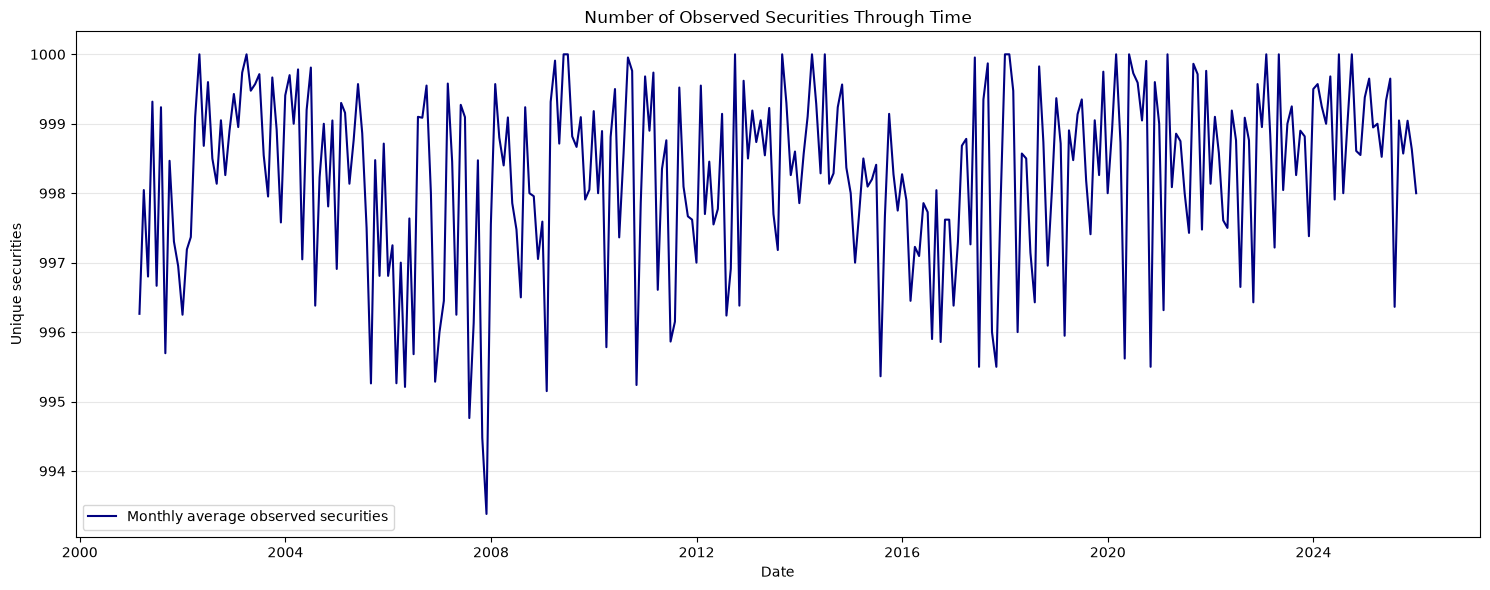

In [8]:
monthly_observed_securities = daily_universe_summary["securities_observed"].resample("ME").mean()

fig, axis = plt.subplots(figsize=(15, 6))
axis.plot(
    monthly_observed_securities.index,
    monthly_observed_securities,
    color="navy",
    linewidth=1.5,
    label="Monthly average observed securities",
)
axis.set(
    title="Number of Observed Securities Through Time",
    xlabel="Date",
    ylabel="Unique securities",
)
axis.grid(axis="y", alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()

## 1.3. Point-in-time top-1,000 market index

Creating a market index to see how the broad market (top 1000 stocks) does overall before going deeper into intra stock correlations.

In [9]:
index_panel = stock_panel.copy()

index_panel["lagged_mcap"] = index_panel.groupby("permno")["mcap"].shift(1)
index_panel["return_for_index"] = index_panel["ret"]

month_end_market_cap = index_panel.loc[index_panel["eligible_mcap"].notna(), ["permno", "month", "mcap", "stock_name"]].sort_values(["month", "permno"]).groupby(["month", "permno"], as_index=False).last()
month_end_market_cap["holding_month"] = month_end_market_cap["month"] + 1
month_end_market_cap = month_end_market_cap.sort_values(["holding_month", "mcap"], ascending=[True, False])
# Rank the largest market-cap securities each month.
month_end_market_cap["market_cap_rank"] = month_end_market_cap.groupby("holding_month").cumcount() + 1
ranked_membership = month_end_market_cap.loc[month_end_market_cap["market_cap_rank"] <= 1_000].copy()

index_panel = index_panel.merge(ranked_membership[["holding_month", "permno", "market_cap_rank"]], left_on=["month", "permno"], right_on=["holding_month", "permno"], how="left", validate="many_to_one")
index_panel["index_eligible"] = (
    index_panel["market_cap_rank"].notna()
    & (index_panel["lagged_mcap"] > 0)
    & index_panel["return_for_index"].notna()
)
index_eligible_panel = index_panel.loc[index_panel["index_eligible"]].copy()

def aggregate_index_returns(day_rows):
    return pd.Series({
        "equal_weighted_return": day_rows["return_for_index"].mean(),
        "cap_weighted_return": np.average(
            day_rows["return_for_index"], weights=day_rows["lagged_mcap"]
        ),
        "securities_used": len(day_rows),
    })

market_index_daily = index_eligible_panel.groupby("date", sort=True).apply(aggregate_index_returns, include_groups=False)
market_index_daily.index = pd.to_datetime(market_index_daily.index)
market_index_daily["equal_weight_cumulative"] = (1 + market_index_daily["equal_weighted_return"]).cumprod()
market_index_daily["cap_weight_cumulative"] = (1 + market_index_daily["cap_weighted_return"]).cumprod()
print(f"Rebalance months: {ranked_membership['holding_month'].nunique():,}")
print(f"Median securities used per day: {market_index_daily['securities_used'].median():,.0f}")
print("Top-1,000 membership with returns in percent and market capitalization in millions of dollars:")
display(format_market_data_for_display(ranked_membership[["holding_month", "permno", "stock_name", "mcap", "market_cap_rank"]].head()))

Rebalance months: 299
Median securities used per day: 974
Top-1,000 membership with returns in percent and market capitalization in millions of dollars:


,holding_month,permno,stock_name,mcap ($ millions),market_cap_rank
63,2001-03,12060,GE,"460,759.293000",1
3,2001-03,10107,MSFT,"314,788.069000",2
156,2001-03,21936,PFE,"283,906.755000",3
53,2001-03,11850,XOM,"281,745.118450",4
515,2001-03,70519,C,"250,262.659440",5


# **2. Initial analysis**

## 2.1. A wholistic view of what the market looks like over time

This is the first section where real analysis begins

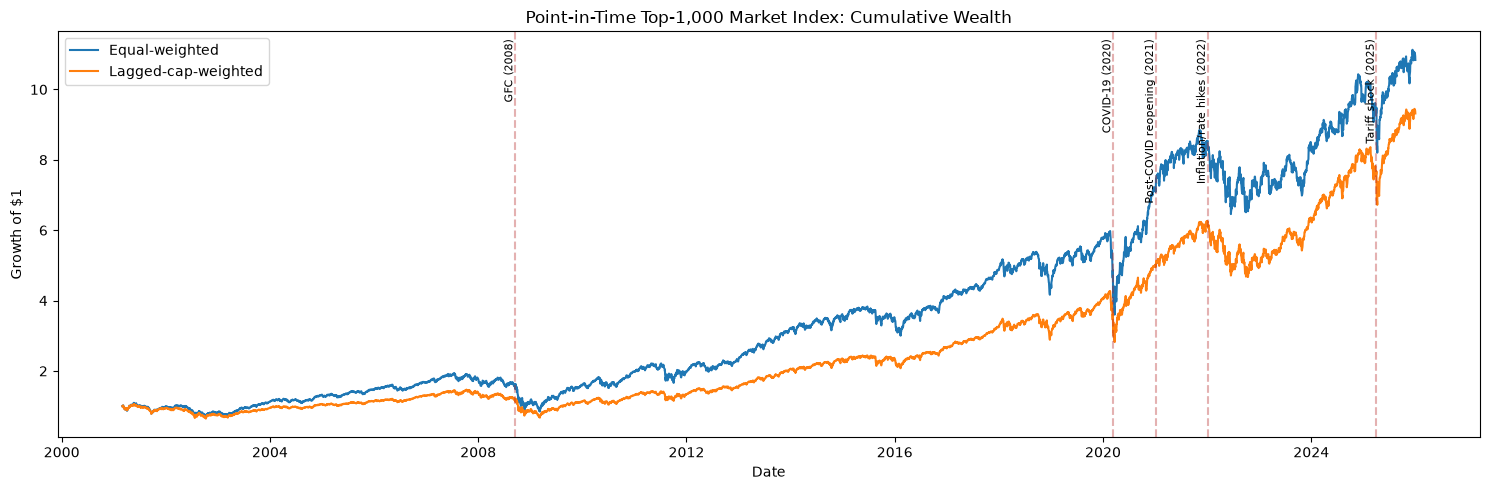

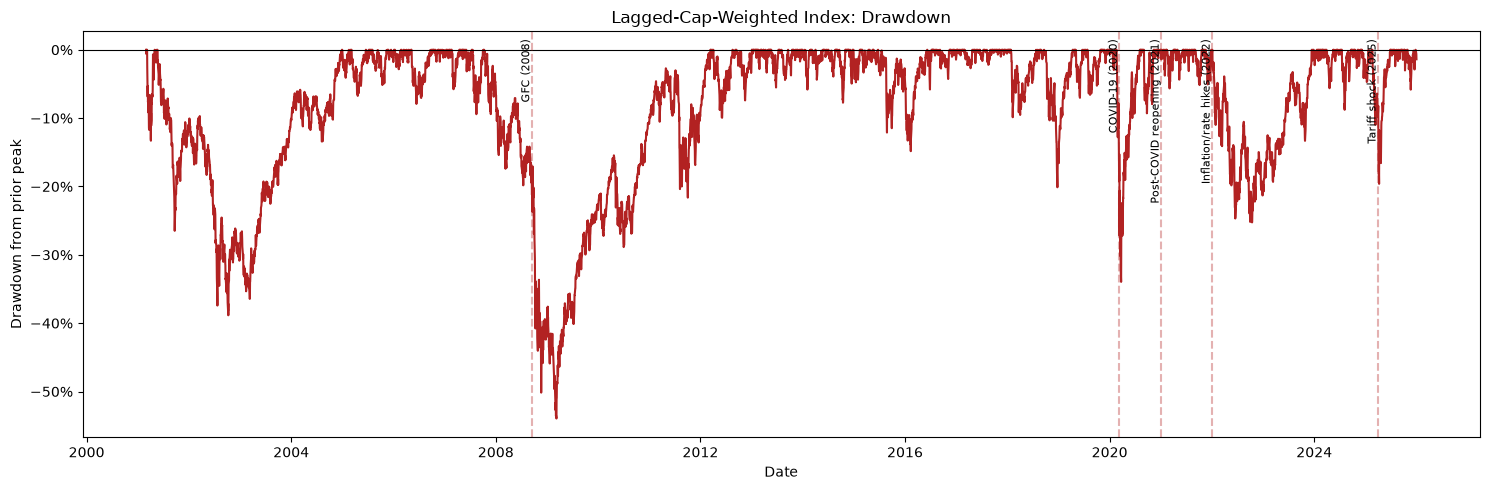

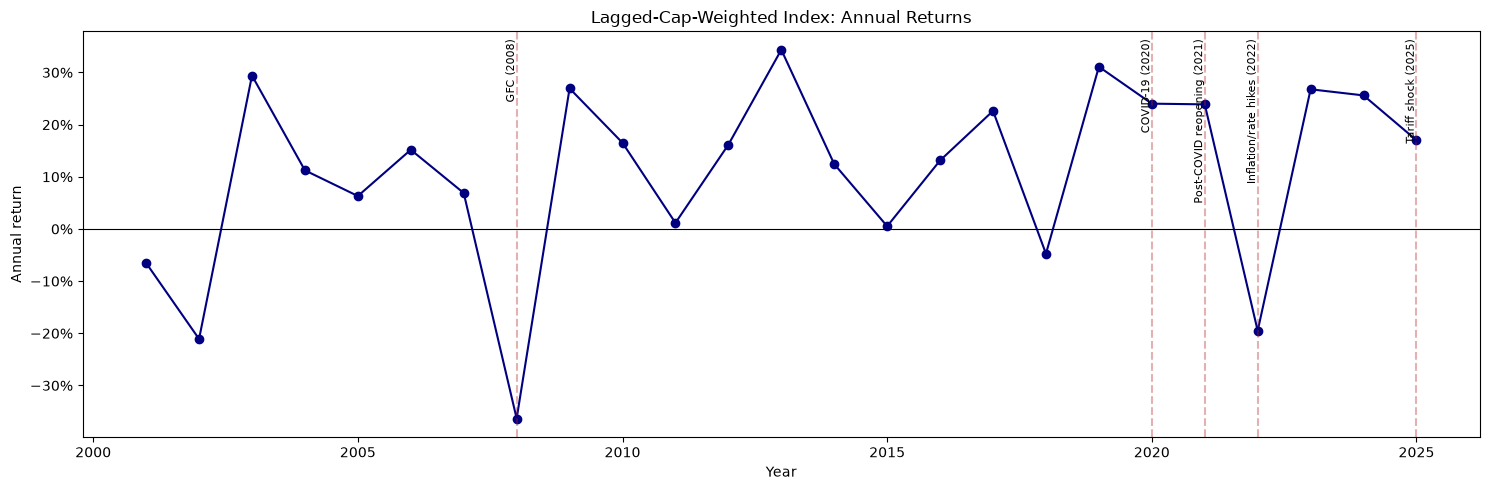

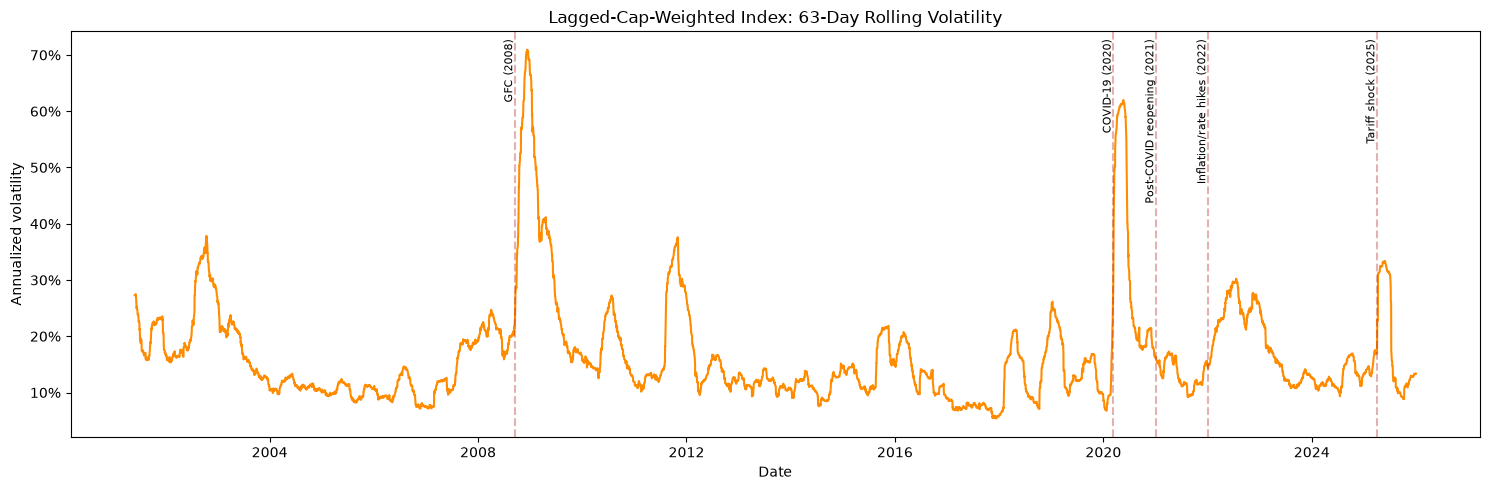

In [10]:
# Keep the overview focused on the lagged-cap-weighted index; compare weighting schemes only in wealth.
cap_weighted_returns = market_index_daily["cap_weighted_return"]
annual_performance = cap_weighted_returns.groupby(cap_weighted_returns.index.year).agg(
    annual_return=lambda values: (1 + values).prod() - 1,
    annualized_volatility=lambda values: values.std() * np.sqrt(252),
)

cap_weighted_wealth = (1 + cap_weighted_returns).cumprod()
cap_weighted_drawdown = cap_weighted_wealth / cap_weighted_wealth.cummax() - 1
annual_performance["maximum_drawdown"] = cap_weighted_drawdown.groupby(cap_weighted_drawdown.index.year).min()

rolling_volatility = cap_weighted_returns.rolling(63).std() * np.sqrt(252)
stress_periods = {
    "GFC": pd.Timestamp("2008-09-15"),
    "COVID-19": pd.Timestamp("2020-03-11"),
    "Post-COVID reopening": pd.Timestamp("2021-01-04"),
    "Inflation/rate hikes": pd.Timestamp("2022-01-03"),
    "Tariff shock": pd.Timestamp("2025-04-02"),
}

def add_stress_markers(axis, annual=False):
    for label, stress_date in stress_periods.items():
        marker = stress_date.year if annual else stress_date
        axis.axvline(marker, color="firebrick", linestyle="--", alpha=0.35)
        axis.text(marker, 0.98, f"{label} ({stress_date.year})", transform=axis.get_xaxis_transform(), rotation=90, va="top", ha="right", fontsize=8)

# 1. Compare the two weighting schemes only in cumulative wealth.
figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(market_index_daily.index, market_index_daily["equal_weight_cumulative"], label="Equal-weighted")
axis.plot(market_index_daily.index, market_index_daily["cap_weight_cumulative"], label="Lagged-cap-weighted")
add_stress_markers(axis)
axis.set(title="Point-in-Time Top-1,000 Market Index: Cumulative Wealth", xlabel="Date", ylabel="Growth of $1")
axis.legend()
figure.tight_layout()
plt.show()

# 2. Drawdown of the lagged-cap-weighted index.
figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(cap_weighted_drawdown, color="firebrick")
axis.axhline(0, color="black", linewidth=0.8)
axis.set(title="Lagged-Cap-Weighted Index: Drawdown", xlabel="Date", ylabel="Drawdown from prior peak")
axis.yaxis.set_major_formatter(PercentFormatter(1))
add_stress_markers(axis)
figure.tight_layout()
plt.show()

# 3. Calendar-year returns of the lagged-cap-weighted index.
figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(annual_performance.index, annual_performance["annual_return"], marker="o", color="navy")
axis.axhline(0, color="black", linewidth=0.8)
axis.set(title="Lagged-Cap-Weighted Index: Annual Returns", xlabel="Year", ylabel="Annual return")
axis.yaxis.set_major_formatter(PercentFormatter(1))
add_stress_markers(axis, annual=True)
axis.yaxis.set_major_formatter(PercentFormatter(1))
figure.tight_layout()
plt.show()

# 4. Changing short-horizon risk of the lagged-cap-weighted index.
figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(rolling_volatility, color="darkorange")
axis.set(title="Lagged-Cap-Weighted Index: 63-Day Rolling Volatility", xlabel="Date", ylabel="Annualized volatility")
axis.yaxis.set_major_formatter(PercentFormatter(1))
add_stress_markers(axis)
figure.tight_layout()
plt.show()

### Summarising Broad Market ###
- Equal weighted index has a higher return than the market-cap weighted index. This is because the equal weighted index gives more weight to smaller stocks which have higher returns on average. This is an expected result.
- In terms of drawdown, GFC has been the worst in this period followed by covid. The period in 2022-2023 looks interesting as well. That is a period that might be worth exploring as well in terms of market stress scenario.
- Continuing the trend of drawdown, volatility shows similar pattern for spikes. Again, GFC and covid would be the periods of interest to study deeper to analyse diversification benefits and correlation structure of the market.

## 2.2. Rolling average pairwise correlation

For each sampled date, a correlation matrix is computed over the trailing 252-day window across the index-eligible universe, then reduced to the average pairwise correlation. Stress periods are highlighted to show how market-wide synchronization changes during crises.

Rolling window: 252 trading days, sampled every 21 days
Maximum top-market-cap securities per window: 250
Evaluation dates: 286
Average pairwise correlation range: 0.135 to 0.567


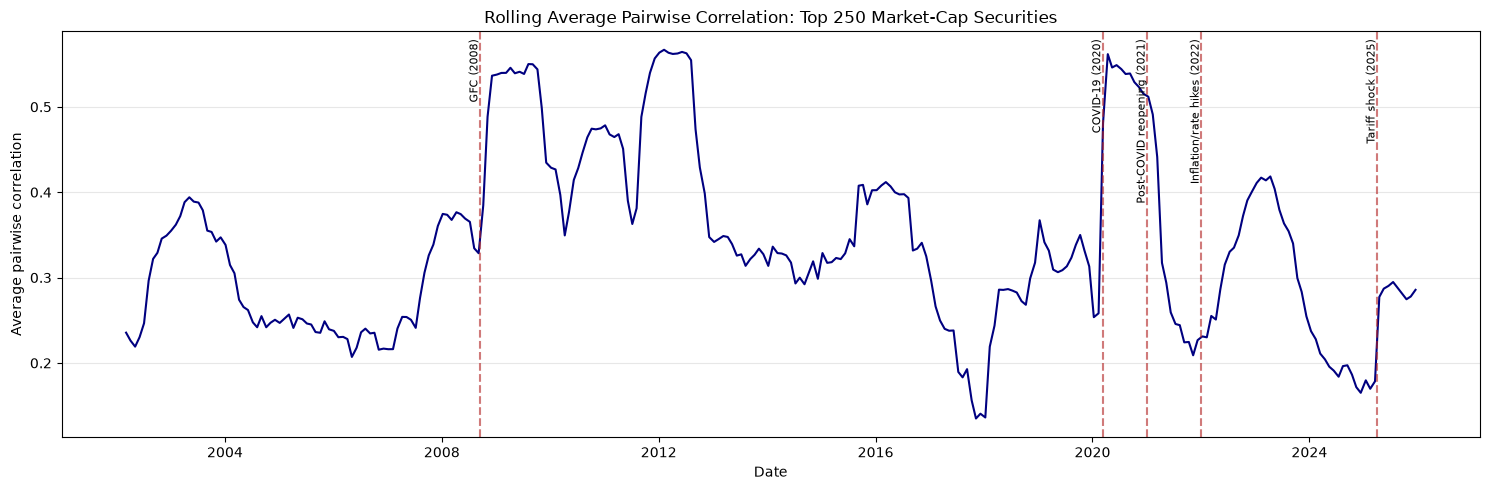

In [11]:
# Cap the rolling correlation matrix at the largest securities by lagged market cap.
rolling_window_days = 252
minimum_observations = 60
evaluation_step = 21
sample_size = 250

correlation_returns = index_eligible_panel.pivot(
    index="date", columns="permno", values="return_for_index"
).sort_index()
market_cap_returns = index_eligible_panel.pivot(
    index="date", columns="permno", values="lagged_mcap"
).reindex(correlation_returns.index)
evaluation_dates = correlation_returns.index[rolling_window_days - 1 :: evaluation_step]

rolling_correlation_rows = []
for evaluation_date in evaluation_dates:
    window_returns = correlation_returns.loc[:evaluation_date].tail(rolling_window_days)
    valid_securities = window_returns.count().loc[lambda counts: counts >= minimum_observations].index
    selected_securities = market_cap_returns.loc[evaluation_date, valid_securities].nlargest(sample_size).index
    window_correlation = window_returns[selected_securities].corr(min_periods=minimum_observations)
    pairwise_correlations = window_correlation.to_numpy()[np.triu_indices(len(selected_securities), k=1)]
    rolling_correlation_rows.append({
        "date": evaluation_date,
        "average_pairwise_correlation": np.nanmean(pairwise_correlations),
        "securities_used": window_correlation.shape[1],
    })

rolling_correlation = pd.DataFrame(rolling_correlation_rows).set_index("date")
print(f"Rolling window: {rolling_window_days} trading days, sampled every {evaluation_step} days")
print(f"Maximum top-market-cap securities per window: {sample_size:,}")
print(f"Evaluation dates: {len(rolling_correlation):,}")
print(f"Average pairwise correlation range: {rolling_correlation['average_pairwise_correlation'].min():.3f} to {rolling_correlation['average_pairwise_correlation'].max():.3f}")

figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(
    rolling_correlation.index,
    rolling_correlation["average_pairwise_correlation"],
    color="navy",
    label="Average pairwise correlation",
)
for label, stress_date in stress_periods.items():
    axis.axvline(stress_date, color="firebrick", linestyle="--", alpha=0.6)
    axis.text(stress_date, 0.98, f"{label} ({stress_date.year})", transform=axis.get_xaxis_transform(), rotation=90, va="top", ha="right", fontsize=8)
axis.set(
    title=f"Rolling Average Pairwise Correlation: Top {sample_size} Market-Cap Securities",
    xlabel="Date",
    ylabel="Average pairwise correlation",
)
axis.grid(axis="y", alpha=0.3)
figure.tight_layout()
plt.show()

### Summarising Rolling Average Pairwise Correlation ###
- As expected, the correlations spike during market stress periods. Here, the GFC and covid periods are interesting to study from a diversification point of view. However, the period of 2012-2013 looks interesting as well with correlations spiking beyond 50%.
- `The 2012–2013 correlation spike` is not a crash but a `macro-driven regime`: the eurozone crisis resolution (LTRO, OMT), Fed QE3, and the fiscal-cliff/taper-tantrum episodes made central-bank policy the dominant driver of all equity returns. In such "risk-on/risk-off" regimes, stocks co-move because they share a common macro factor, not because of panic-driven deleveraging. This distinction matters: high correlation from a macro regime is persistent and policy-dependent, whereas crash-driven correlation is acute and mean-reverting.

# **3. PCA**

We use a 504-day rolling window for PCA decomposition. We use the exponentially-weighted covariance matrix with 252-day half life. The matrix is shrunk for stabilization purposes. 

## 3.1. Constructing the data universe

Each day, keep the top 500 stocks by mcap. If any of these stocks has any missing return for the past 504 (or defined window size) days, then discard that stock and keep the next available stock by market cap that satisfies the window requirement.

In [12]:
N_STOCKS = 500
WINDOW = 504


### Upload data
data = pd.read_parquet(DATA_PATH)
data = data[["permno","ticker","date", "ret", "mcap", "close", "sic2"]].copy()
data["date"] = pd.to_datetime(data["date"])
data["ret"] = data["ret"].astype("float64")
data["mcap"] = data["mcap"].astype("float64")

### Construct universe
# Pivot returns and marketcap
ret_wide = data.pivot(index="date", columns="permno", values="ret").sort_index()
mcap_wide = data.pivot(index="date", columns="permno", values="mcap").sort_index()

# For each day, does each stock have a FULL 504-day trailing history (no gaps)?
has_full_history = ret_wide.notna().rolling(WINDOW).sum() == WINDOW

dates = ret_wide.index

universe = {} 

for t in dates:
    eligible_mask = has_full_history.loc[t]
    eligible = eligible_mask[eligible_mask].index      # stocks with full history as of t

    if len(eligible) == 0:
        continue

    mcap_t = mcap_wide.loc[t, eligible].dropna()
    top500 = mcap_t.nlargest(N_STOCKS).index           # largest 500 stocks that satisfy requirements

    universe[t] = list(top500)


# Diagnostics: how many eligible names per day, and how many days actually hit 500
eligible_count = has_full_history.sum(axis=1)
selected_count = pd.Series({t: len(v) for t, v in universe.items()})

# First date where a full 504-day window is even possible
burn_in_date = dates[WINDOW - 1]

# Restrict diagnostics to dates on/after burn-in
eligible_count_post = eligible_count.loc[burn_in_date:]
selected_count_post = selected_count.loc[burn_in_date:]  # universe dict already only has post-burn-in dates

print(eligible_count_post.describe())
print("\nDays with fewer than 500 eligible names:", 
      (eligible_count_post < N_STOCKS).sum(), "out of", len(eligible_count_post))



count   5,763.000000
mean      767.655908
std        27.215623
min       677.000000
25%       752.000000
50%       773.000000
75%       784.000000
max       825.000000
dtype: float64

Days with fewer than 500 eligible names: 0 out of 5763


## 3.2. Running PCA

In [13]:
HALFLIFE = 252
SHRINKAGE_TARGET = "constant_correlation"
SMOOTH_WINDOW = 60


# Shrinkage factor estimation
raw_deltas = {}
for t, permnos in universe.items():
    i = dates.get_loc(t)
    window_dates = dates[i - WINDOW + 1 : i + 1]
    R = ret_wide.loc[window_dates, permnos].values
    raw_deltas[t] = pca_functions.ewma_shrinkage_delta(R, HALFLIFE, target=SHRINKAGE_TARGET)

raw_delta_series = pd.Series(raw_deltas).sort_index()

# Smooth shinkage factor
smoothed_delta_series = raw_delta_series.rolling(SMOOTH_WINDOW, min_periods=1).mean().shift(1)
smoothed_delta_series.iloc[0] = raw_delta_series.iloc[0]   # first day has no history to smooth over


# Run PCA

pca_results = {}  
for t, permnos in universe.items():
    i = dates.get_loc(t)
    window_dates = dates[i - WINDOW + 1 : i + 1]

    R = ret_wide.loc[window_dates, permnos].values 

    # Standarize returns (using ewma calculations)
    ewma_mean, ewma_sigma = pca_functions.ewma_mean_std(R, HALFLIFE)
    R_std = (R - ewma_mean) / ewma_sigma 

    # EWMA Covariance of standarized returns
    cov = pca_functions.ewma_cov(R_std, HALFLIFE)        

    # Shrinkage factor
    delta = smoothed_delta_series[t]

    # Shrink covariance matrix
    cov = pca_functions.shrink_cov_matrix(cov, delta=delta, target=SHRINKAGE_TARGET)

    # PCA decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)           
    eigvals, eigvecs = eigvals[::-1], eigvecs[:, ::-1]
    eigvals = np.clip(eigvals, 0, None)                 # Make sure there are no negative eigenvalues due to floating point error

    # Explained variance ratio for each eigenvalue
    explained_var_ratio = eigvals / eigvals.sum()

    pca_results[t] = {
        "permnos": permnos,
        "eigvals": eigvals.astype(np.float32),
        "eigvecs": eigvecs.astype(np.float32),
        "sigma": ewma_sigma.astype(np.float32),
        "explained_var_ratio": explained_var_ratio.astype(np.float32),
        "delta": delta,
        "delta_raw": raw_delta_series[t],
    }

## 3.3. Plots

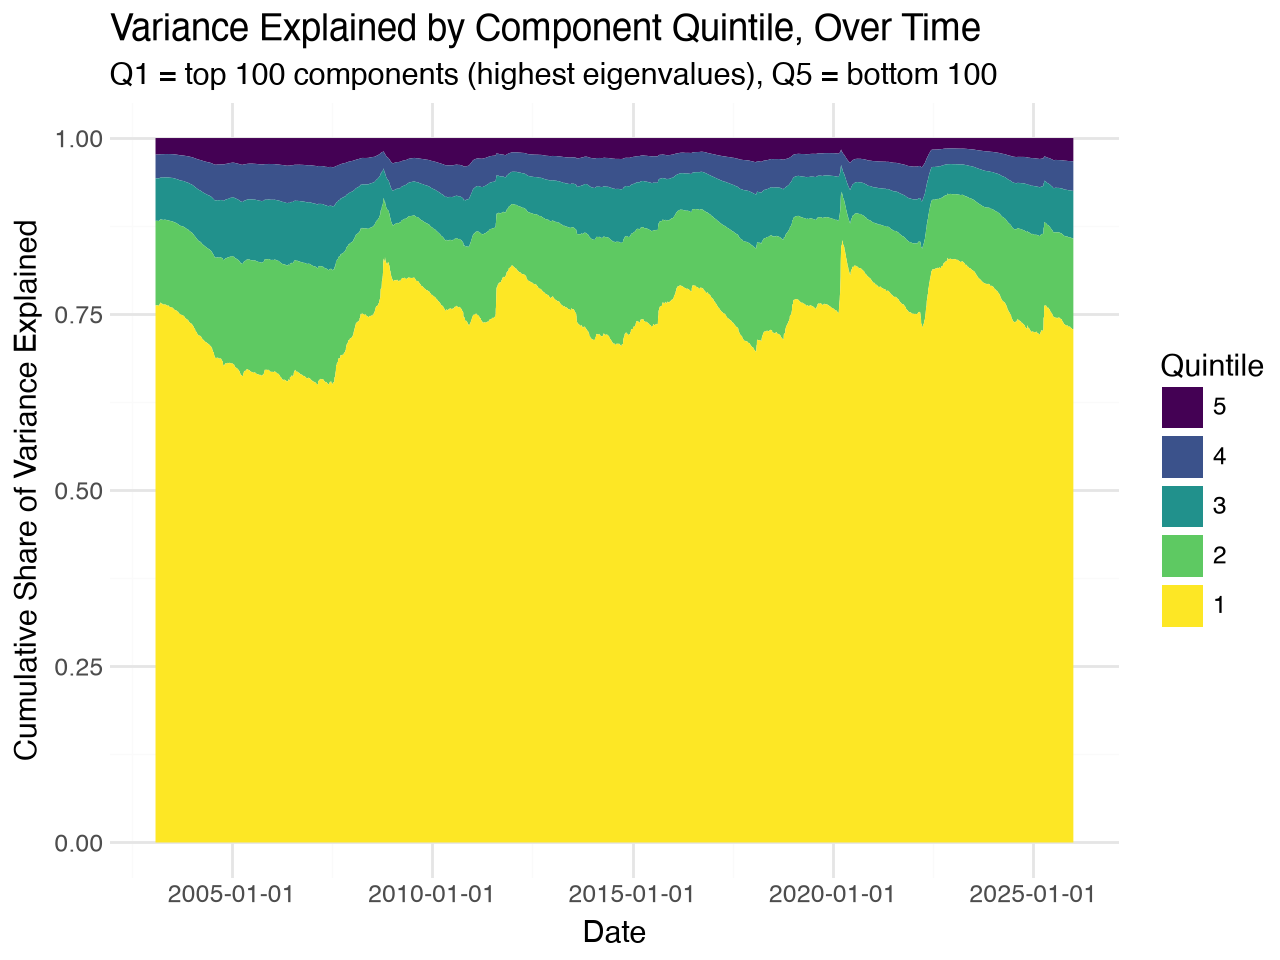

In [14]:
N_QUINTILES = 5

records = []
for t, res in pca_results.items():
    evr = res["explained_var_ratio"]          # length 500, full rank, sums to 1
    n = len(evr)
    q_size = n // N_QUINTILES

    for q in range(N_QUINTILES):
        start = q * q_size
        end = (q + 1) * q_size if q < N_QUINTILES - 1 else n
        records.append({
            "date": t,
            "quintile": q + 1,
            "var_explained": evr[start:end].sum()
        })

df_q = pd.DataFrame(records)

# Reverse order (5,4,3,2,1) so Q1 (largest eigenvalues) stacks at the BOTTOM of the chart
df_q["quintile"] = pd.Categorical(df_q["quintile"], categories=[5, 4, 3, 2, 1], ordered=True)

p = (
    p9.ggplot(df_q, p9.aes(x="date", y="var_explained", fill="quintile"))
    + p9.geom_area(position="stack")
    + p9.labs(
        title="Variance Explained by Component Quintile, Over Time",
        subtitle="Q1 = top 100 components (highest eigenvalues), Q5 = bottom 100",
        x="Date",
        y="Cumulative Share of Variance Explained",
        fill="Quintile"
    )
    + p9.theme_minimal()
)
p

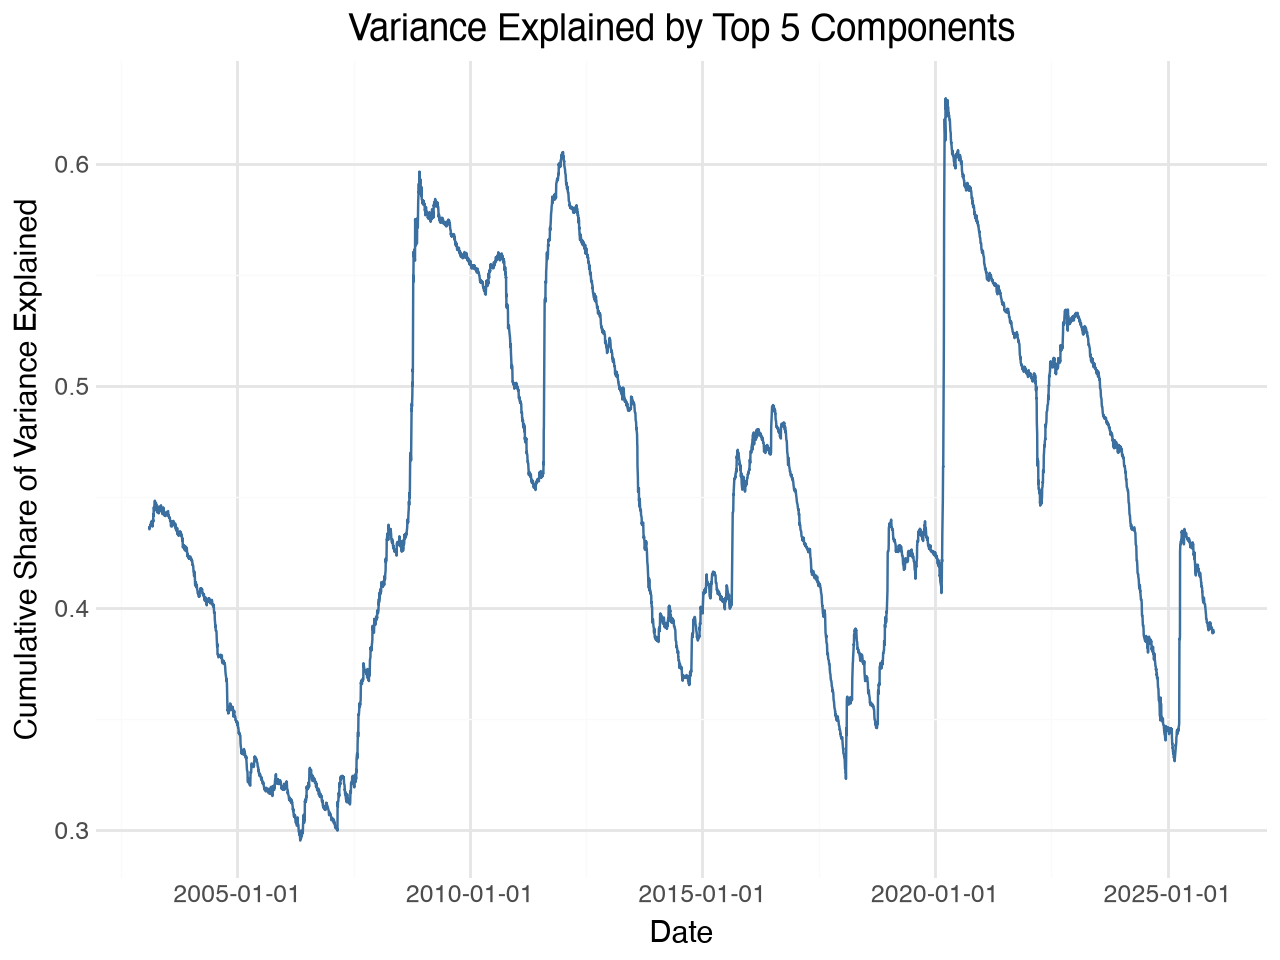

In [15]:
top_n = 5

records_topn = []
for t, res in pca_results.items():
    evr = res["explained_var_ratio"]         # length 500, sorted descending, sums to 1
    records_topn.append({
        "date": t,
        "var_topn": evr[:top_n].sum()
    })

df_top100 = pd.DataFrame(records_topn)

p1 = (
    p9.ggplot(df_top100, p9.aes(x="date", y="var_topn"))
    + p9.geom_line(color="#3b6fa0")
    + p9.labs(
        title=f"Variance Explained by Top {top_n} Components",
        x="Date",
        y="Cumulative Share of Variance Explained"
    )
    + p9.theme_minimal()
)
p1

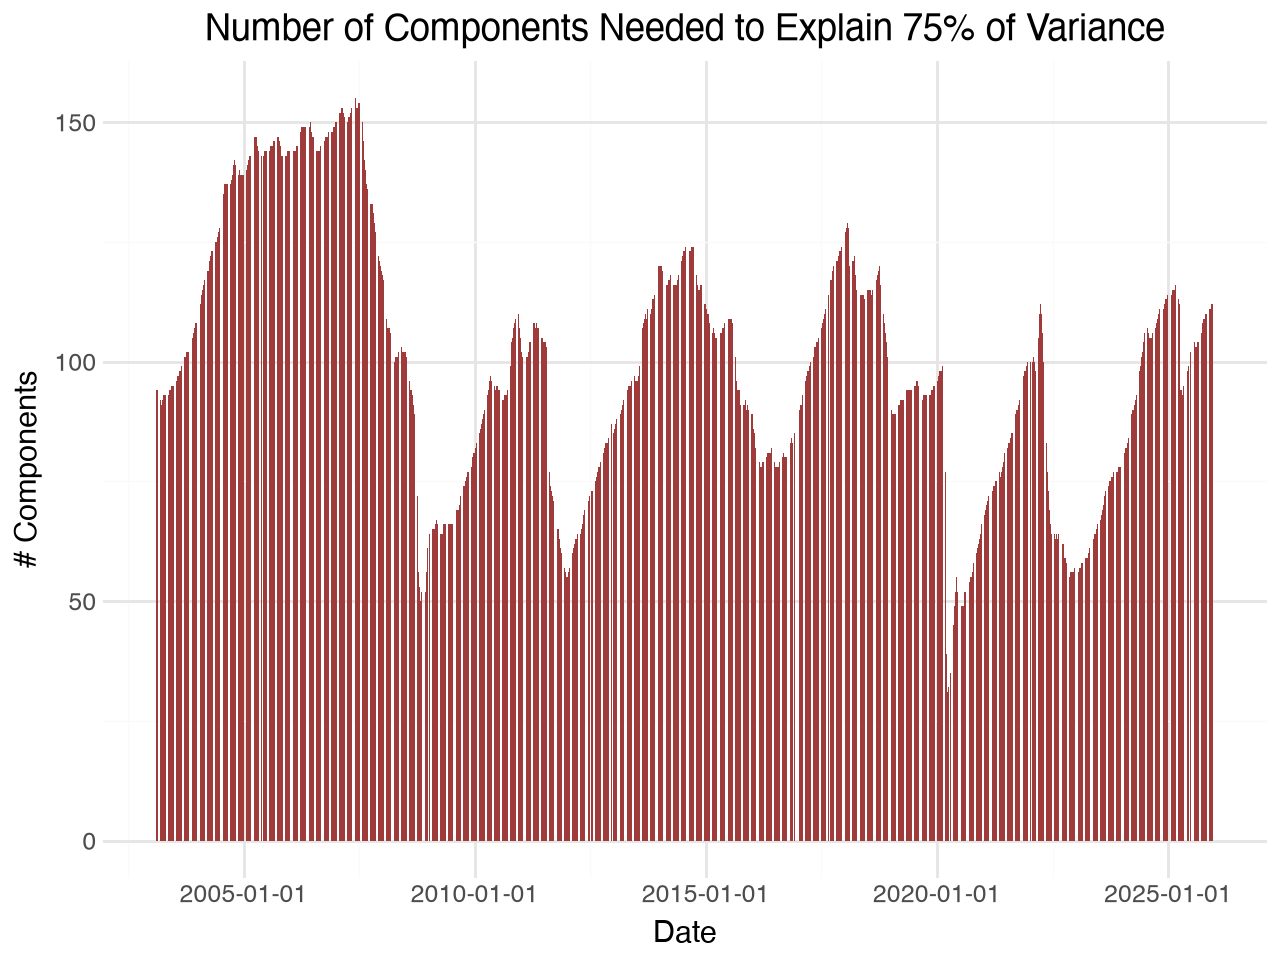

In [16]:
THRESHOLD = 0.75

records_n75 = []
for t, res in pca_results.items():
    evr = res["explained_var_ratio"]
    cum = np.cumsum(evr)                      # running total: cum[k] = variance explained by first k+1 PCs
    n_needed = int(np.searchsorted(cum, THRESHOLD, side="left") + 1)
    records_n75.append({"date": t, "n_components_75": n_needed})

df_n75 = pd.DataFrame(records_n75)

p2 = (
    p9.ggplot(df_n75, p9.aes(x="date", y="n_components_75"))
    + p9.geom_col(fill="#a03b3b", width=1.0)
    + p9.labs(
        title="Number of Components Needed to Explain 75% of Variance",
        x="Date",
        y="# Components"
    )
    + p9.theme_minimal()
)
p2

## 3.4. Additional plots

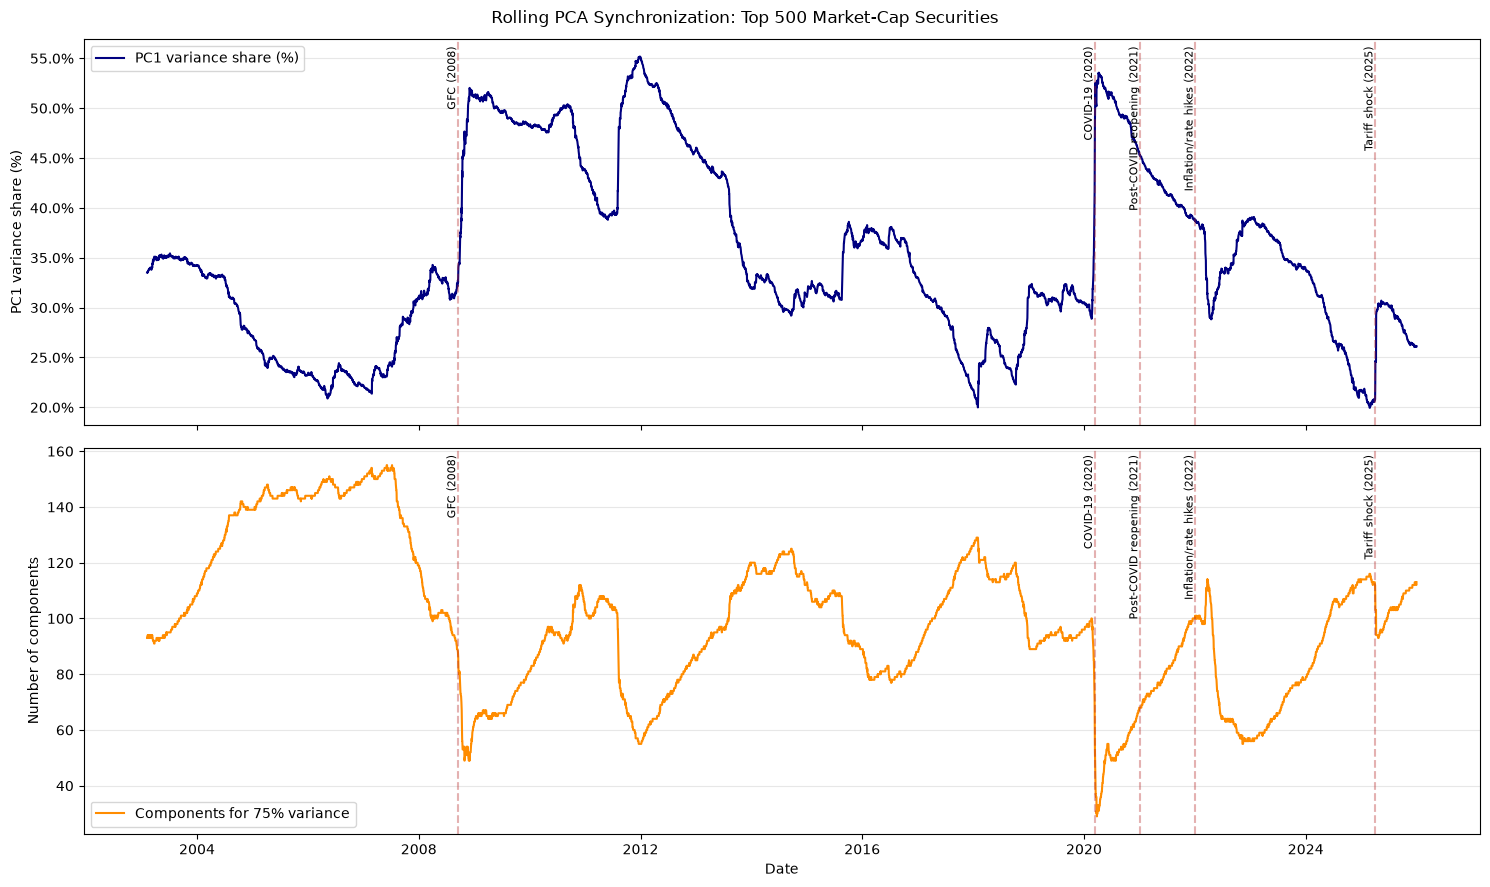

In [17]:
# --- Build the summary DataFrame from pca_results ---
def components_for_variance_threshold(explained_var_ratio, threshold=0.75):
    cumsum = np.cumsum(explained_var_ratio)
    return int(np.searchsorted(cumsum, threshold) + 1)

pca_summary_rows = []
for t, r in pca_results.items():
    pca_summary_rows.append({
        "date": t,
        "first_component_variance_share": r["explained_var_ratio"][0],
        "components_for_75pct_variance": components_for_variance_threshold(r["explained_var_ratio"], 0.75),
        "securities_used": len(r["permnos"]),
        "delta": r["delta"],
        "delta_raw": r["delta_raw"],
    })

pca_summary = pd.DataFrame(pca_summary_rows).set_index("date").sort_index()

# --- Plot ---
figure, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

axes[0].plot(
    pca_summary.index,
    pca_summary["first_component_variance_share"],
    color="navy",
    label="PC1 variance share (%)",
)
axes[0].set_ylabel("PC1 variance share (%)")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend()

axes[1].plot(
    pca_summary.index,
    pca_summary["components_for_75pct_variance"],
    color="darkorange",
    label="Components for 75% variance",
)
axes[1].set_ylabel("Number of components")
axes[1].set_xlabel("Date")
axes[1].legend()

for axis in axes:
    add_stress_markers(axis)   # assumes this helper is already defined elsewhere in your notebook
    axis.grid(axis="y", alpha=0.3)

figure.suptitle(f"Rolling PCA Synchronization: Top {N_STOCKS} Market-Cap Securities")
figure.tight_layout()
plt.show()

### Summarising Rolling PCA - market-wide synchronization ###
- The first component variance (PC1) share is a measure of how much of the total variance in the data is explained by the first principal component. A higher value indicates that a single factor (the first principal component) is driving the returns of the stocks in the market. This is often interpreted as a measure of market-wide synchronization, where a higher value suggests that the market is more synchronized and that individual stock returns are more influenced by common factors rather than idiosyncratic factors.
- As we would expect, the PC1 variance share spikes during market stress scenarios. Also, during these scenarios, since the PC1 variance share goes up, the number of componennts needed to explain 75% of the total variance goes down.
- As noted in the correlation analysis, the 2012-2013 period shows market synchrinisation as well. This is consistent with the correlation analysis and further supports the idea that this period was driven by macro factors rather than idiosyncratic shocks.

### 3.4.a. PC1 loading concentration

The effective number of stocks is the inverse Herfindahl index of the unit-norm PC1 eigenvector loadings. It estimates how many stocks effectively drive PC1: values near 500 indicate broad-based loading, while values near 1 indicate concentration in a small number of stocks.

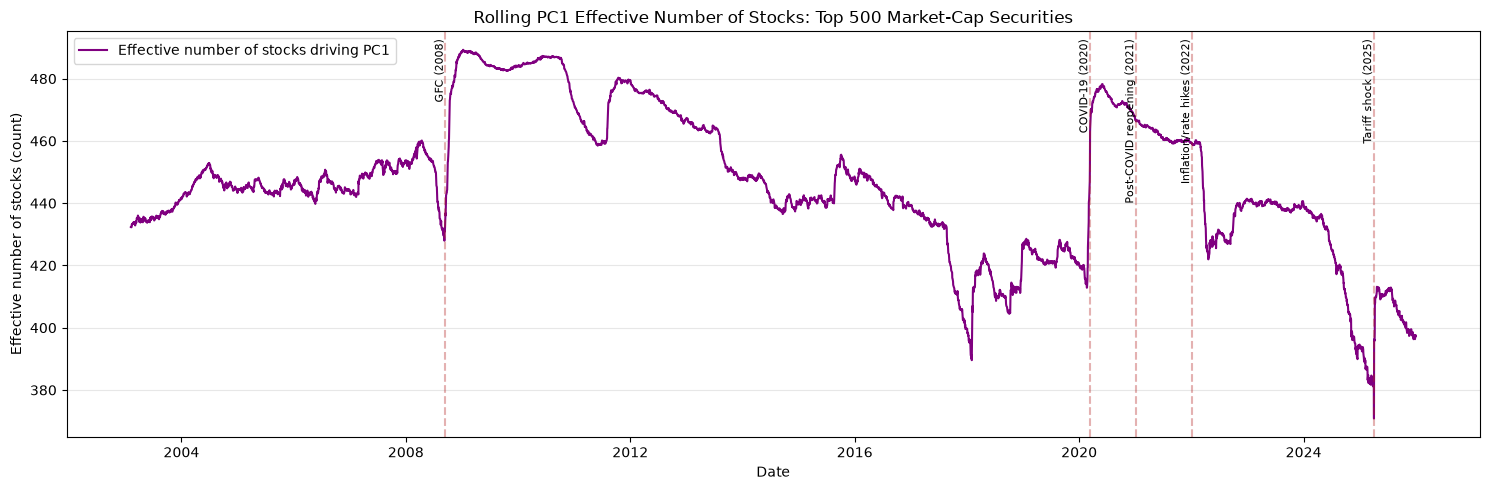

In [18]:
def pc1_effective_number_of_stocks(pca_result):
    pc1_loadings = pca_result["eigvecs"][:, 0].astype(np.float64)
    p_i = pc1_loadings ** 2          # sums to 1 automatically (eigvec is unit-norm)
    return div_functions.n_hhi(p_i)                 # reuses your existing HHI-based ENB function


pca_loading_concentration_rows = []
for t, r in pca_results.items():
    pca_loading_concentration_rows.append({
        "date": t,
        "pc1_effective_number_of_stocks": pc1_effective_number_of_stocks(r),
    })

pca_loading_concentration = pd.DataFrame(pca_loading_concentration_rows).set_index("date").sort_index()

figure, axis = plt.subplots(figsize=(15, 5))
axis.plot(pca_loading_concentration, color="purple", label="Effective number of stocks driving PC1")
axis.set(
    title=f"Rolling PC1 Effective Number of Stocks: Top {N_STOCKS} Market-Cap Securities",
    xlabel="Date",
    ylabel="Effective number of stocks (count)",
)
axis.legend()
axis.grid(axis="y", alpha=0.3)
add_stress_markers(axis)
figure.tight_layout()
plt.show()

`Effective number of stocks driving PC1`
- THE HHI is typically used to show market concentration and the reciprocal can be used to study effective number of stocks. We use something similar here but the interpretation of the effective number is flipped here in terms of diversification since we are using HHI for PC1. When studying markert concentration, higher 1/HHI means more stocks are represented in the market. Here, a higher number for PC1 loadings means that more stocks are represented in the loadings for PC1. PC1 is the direction of maximum variance. When more stocks have meaningful loadings on it, they all move with the same dominant factor — so a high effective number of stocks driving PC1 implies less diversification.
- We can see that the effective number of loadings driving PC1 spikes during stress periods, indicating lower diversification as the dominant factor broadens across the market (stocks co-move more).
- The period of 2017-2018 has a lower number of stocks driving PC1 which is consistent with the correlation analysis. It could be interesting to study what causes this behavior.

### 3.4.b. Scree plot at representative dates

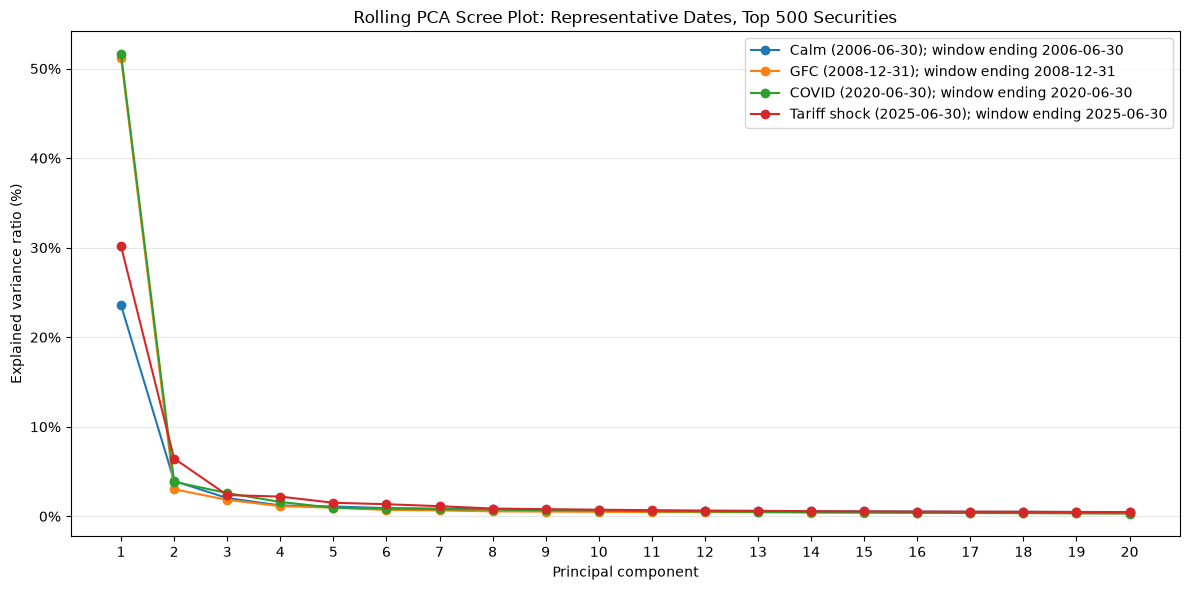

In [19]:
representative_pca_dates = {
    "Calm (2006-06-30)": pd.Timestamp("2006-06-30"),
    "GFC (2008-12-31)": pd.Timestamp("2008-12-31"),
    "COVID (2020-06-30)": pd.Timestamp("2020-06-30"),
    "Tariff shock (2025-06-30)": pd.Timestamp("2025-06-30"),
}

pca_dates_sorted = sorted(pca_results.keys())

figure, axis = plt.subplots(figsize=(12, 6))
for label, requested_date in representative_pca_dates.items():
    available_dates = [d for d in pca_dates_sorted if d <= requested_date]
    if not available_dates:
        print(f"No rolling PCA window available on or before {requested_date.date()} for {label}.")
        continue
    selected_date = max(available_dates)
    explained_variance_ratios = pca_results[selected_date]["explained_var_ratio"]
    component_count = min(20, len(explained_variance_ratios))
    axis.plot(
        np.arange(1, component_count + 1),
        explained_variance_ratios[:component_count],
        marker="o",
        linewidth=1.5,
        label=f"{label}; window ending {selected_date.date()}",
    )

axis.set(
    title=f"Rolling PCA Scree Plot: Representative Dates, Top {N_STOCKS} Securities",
    xlabel="Principal component",
    ylabel="Explained variance ratio (%)",
)
axis.yaxis.set_major_formatter(PercentFormatter(1))
axis.set_xticks(np.arange(1, 21))
axis.grid(axis="y", alpha=0.3)
axis.legend()
figure.tight_layout()
plt.show()

# **4. Diversification**

## **Measuring diversification of a given portfolio**

Before defining and measuring the diversification of a given portfolio construction method, we need to project the portfolio's weights onto the eigenspace and compute the portfolio's score on each principal component. Our measures of diversification will use the scores as input.

We performed the PCA decomposition on standarized returns (correlation matrix), but we are interested in measuring the diversification of a portfolio in the real world, where assets have different volatilities. In other words, our eigenvectors and real world portfolios live in different spaces. Before projecting the portfolio onto the eigenvectors, we therefore need to re-express the portfolio's weights in standardized returns units, so that the resulting variance decomposition is measured in a consistent space.

The end goal is to express the portfolio variance in terms of the uncorrelated sources of risk. Let's start by expresing the portfolio's variance in terms of the raw covariance matrix:

$$
\sigma_p^2 = w^\top \Sigma w
$$

where $\sigma_p^2$ is the portfolio's variance, $w$ is the vector of weights, and $\Sigma$ is the raw covariance matrix. 

The covariance matrix can be expressed in terms of the correlation matrix:

$$
\Sigma = D\,C\,D
$$

where $C$ is the correlation matrix and $D = \text{diag}(\sigma_1, \dots, \sigma_N)$.

Substituting, we have:

$$
\sigma_p^2 = w^\top \Sigma w = w^\top (D C D) w = (w^\top D)\, C\, (D w) = (Dw)^\top\, C\, (D w)
$$

The last step follows since $D$ is diagonal (and thus, symmetric), so $ w^\top D = (D^\top w)^\top = (Dw)^\top$.

The term $Dw$ is multiplying a diagonal matrix of the volatilities by the vector of weights, which results in a vector of weights scaled by the volatility. In other words, the entries of this resulting vector are the original portfolio weights multiplied by the each asset volatility ($\sigma_i w_i$). We will define $u := Dw$, so $u_i = \sigma_i w_i$.

-----

Now, we want to decompose the variance of the portfolio using the principal components.

In the steps above, we showed that 

$$
\sigma_p^2 = u^\top C u
$$

We have already decomposed the correlation matrix, so the equation above becomes:


$$
\sigma_p^2 = u^\top (V \Lambda V^\top) u
$$

where $V$ is the matrix of eigenvectors and $\Lambda = \text{diag}(\lambda_1, \dots, \lambda_N)$.

Rearranging:

$$
\sigma_p^2 = u^\top (V \Lambda V^\top) u = (u^\top V) \Lambda (V^\top u) = (V^\top u)^\top \Lambda (V^\top u)
$$

The term $V^\top u$ is the projection of the portfolio weights on the eigenvectors. We can further define $s = V^\top u$ and the portfolio variance becomes:

$$
\sigma_p^2 = s^\top \Lambda s = \sum_{k=1}^N \lambda_k s_k^2
$$

where the last term comes from the vector and matrix multiplication, given that the matrix $\Lambda$ is diagonal.

In plain words, the portfolio variance is the sum of the product of eigenvalues and the squared projection of the portfolio weights on the eigenvectors (the square of the scores). Each term $\lambda_k s_k^2$ is the portfolio variance attributable to component $k$.

----

For our diversification measures, we are interested in the fraction of portfolio variance explained by each component:

$$
p_k = \frac{\lambda_k\, s_k^2}{\sum_{j=1}^{N} \lambda_j\, s_j^2}
$$


The distribution of $\{p_k\}$ is the input for the diversification measures.


## **Diversification measures**

Intuitively, the concept of diversification is closely related to the fraction of portfolio variance explained by each component. A highly diversified portfolio should have a similar fraction of variance explained by each component, while a portfolio with low diversification should have a large portion of the variance explained by a few components. We can try to measure diversification by assesing how concentrated is the variance explained by the components.


1. **Entropy-based measure of diversification (Meucci, 2010):**

$$
N_{ent} = \exp\left(-\sum_k p_k\ln p_k\right)
$$

This formula measures the dispersion of the distribution of $\{p_k\}$. For a completely concentrated portfolio, $N_{ent} = 0$. For a completely diversified portfolio, $N_{ent} = K$. In essence, $N_{ent}$ is the effective number of uncorrelated risk sources.


2. **Herfindahl–Hirschman index measure of diversification**


$$
N_{HHI} = \frac{1}{\sum_k p_k^2}
$$

We use the inverse instead of the raw HHI (\sum_k p_k^2) to be consistent with the $N_{ent}$ measure. Higher $N_{HHI}$ reflects more diversification.


3. **Fraction of variance explained by top N components**

$$
\ {Var}_{topN} = \sum_{k=1}^{N} p_k
$$

This is an equivalent measure to the Absorption Ratio in (Kritzman, Li, Page & Rigobon, 2010).

### 4.1. Build portfolios

In [20]:

PORTFOLIOS_PATH = PROJECT_ROOT / "data" / "portfolios.pkl"

if not PORTFOLIOS_PATH.exists():
    # Main loop
    portfolios = {}
    erc_converged_by_date = {}
    fallback_stats = {"min_var_failed": 0, "max_div_failed": 0, "erc_not_converged": 0, "n_dates": 0}

    for t, pca_result in pca_results.items():
        permnos = pca_result["permnos"]
        rho, sigma = port_functions.reconstruct_cov_shrunk(pca_result)
        Sigma = np.outer(sigma, sigma) * rho

        min_var_w = port_functions.min_variance_weights_qp(Sigma, permnos)
        max_div_w = port_functions.max_diversification_weights_qp(rho, sigma, permnos)
        erc_w, erc_converged = port_functions.erc_weights_newton(Sigma, permnos)

        portfolios[t] = {
            "equal_weight": port_functions.equal_weight_portfolio(permnos),
            "mcap":         port_functions.mcap_weight_portfolio(permnos, mcap_wide, t),
            "min_var":      min_var_w,
            "erc":          erc_w,
            "max_div":      max_div_w,
        }

        erc_converged_by_date[t] = erc_converged
        fallback_stats["n_dates"] += 1
        fallback_stats["min_var_failed"] += int(min_var_w is None)
        fallback_stats["max_div_failed"] += int(max_div_w is None)
        fallback_stats["erc_not_converged"] += int(not erc_converged)

    print(fallback_stats)

    PORTFOLIOS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(PORTFOLIOS_PATH, "wb") as f:
        pickle.dump(portfolios, f, protocol=pickle.HIGHEST_PROTOCOL)

else:
    with open(PORTFOLIOS_PATH, "rb") as f:
        portfolios = pickle.load(f)

    print(f"Loaded {len(portfolios)} dates from {PORTFOLIOS_PATH}")

{'min_var_failed': 0, 'max_div_failed': 0, 'erc_not_converged': 0, 'n_dates': 5763}


In [21]:

portfolios_smoothed = {}
for name in ["min_var", "erc", "max_div"]:
    smoothed_name = port_functions.smoothed_portfolio_dict(portfolios, name, window=20)
    for t, w in smoothed_name.items():
        portfolios_smoothed.setdefault(t, {})[name] = w

# equal_weight/mcap stay untouched, aligned to the same (shorter) date range
for t in portfolios_smoothed:
    portfolios_smoothed[t]["equal_weight"] = portfolios[t]["equal_weight"]
    portfolios_smoothed[t]["mcap"] = portfolios[t]["mcap"]


# Store portfolios dictionary to avoid re-running
with open(PROJECT_ROOT / "data" / "portfolios_smoothed.pkl", "wb") as f:
    pickle.dump(portfolios_smoothed, f, protocol=pickle.HIGHEST_PROTOCOL)

### 4.2. Calculate diversification measures

In [22]:
# Retrieve cached data
with open(PROJECT_ROOT / "data" / "portfolios_smoothed.pkl", "rb") as f:
    portfolios_smoothed = pickle.load(f)


# Run diversification measures

PORTFOLIO_NAMES = ["equal_weight", "mcap", "min_var", "erc", "max_div"]

def build_diversification_panel(portfolios, pca_results, top_n=10):
    records = []

    for t, pca_result in pca_results.items():
        port_t = portfolios.get(t)
        if port_t is None:
            continue

        # Universe-level absorption ratio: property of Sigma's spectrum alone,
        # identical across all portfolios on this date -- computed once per date
        absorption_ratio = float(np.cumsum(pca_result["explained_var_ratio"])[top_n - 1])

        for name in PORTFOLIO_NAMES:
            weights = port_t.get(name)
            if weights is None:              # QP/Newton failed for this portfolio on this date
                continue

            measures = div_functions.compute_diversification_measures(weights, pca_result, top_n=top_n)
            if measures is None:              # total_var <= 0, degenerate case
                continue

            records.append({
                "date": t,
                "portfolio": name,
                "portfolio_variance": measures["portfolio_variance"],
                "enb_entropy": measures["enb_entropy"],
                "enb_hhi": measures["enb_hhi"],
                f"top_{top_n}_var_explained": measures[f"top_{top_n}_var_explained"],
                "absorption_ratio": absorption_ratio,
            })

    panel = pd.DataFrame(records)
    panel["portfolio"] = panel["portfolio"].astype("category")
    panel["date"] = pd.to_datetime(panel["date"])
    return panel.sort_values(["portfolio", "date"]).reset_index(drop=True)

In [23]:

panel = build_diversification_panel(portfolios_smoothed, pca_results, top_n=10)
panel.head()

,date,portfolio,portfolio_variance,enb_entropy,enb_hhi,top_10_var_explained,absorption_ratio
0,2003-03-06,equal_weight,0.000224,1.087092,1.024033,0.999119,0.489627
1,2003-03-07,equal_weight,0.000224,1.086796,1.023993,0.999141,0.489601
2,2003-03-10,equal_weight,0.000225,1.084055,1.023322,0.999189,0.492200
3,2003-03-11,equal_weight,0.000224,1.081216,1.022288,0.999206,0.492088
4,2003-03-12,equal_weight,0.000223,1.081440,1.022327,0.999187,0.491672


### Summary stats for diversification measures

In [24]:
panel.groupby("portfolio", observed=True)[["enb_entropy", "enb_hhi", "top_10_var_explained"]].describe().T

portfolio                   equal_weight          erc      max_div  \
enb_entropy          count  5,744.000000 5,744.000000 5,744.000000   
                     mean       1.052817     1.063730     5.313048   
                     std        0.023117     0.054750     1.566890   
                     min        1.011863     1.003110     2.423147   
                     25%        1.033345     1.027689     4.110321   
                     50%        1.051630     1.044987     5.195206   
                     75%        1.070297     1.080303     6.254951   
                     max        1.139212     1.259379     9.894342   
enb_hhi              count  5,744.000000 5,744.000000 5,744.000000   
                     mean       1.013426     1.018111     1.895957   
                     std        0.006491     0.018722     0.317730   
                     min        1.002409     1.000492     1.326981   
                     25%        1.007982     1.005934     1.652343   
                     50%        1.012977     1.010327     1.877284   
                     75%        1.018481     1.022057     2.107002   
                     max        1.037189     1.095487     2.851123   
top_10_var_explained count  5,744.000000 5,744.000000 5,744.000000   
                     mean       0.999326     0.999257     0.845464   
                     std        0.000491     0.000608     0.039679   
                     min        0.996783     0.996211     0.686748   
                     25%        0.999174     0.999039     0.816006   
                     50%        0.999366     0.999317     0.853968   
                     75%        0.999705     0.999739     0.873735   
                     max        0.999915     0.999926     0.925039   

portfolio                          mcap      min_var  
enb_entropy          count 5,744.000000 5,744.000000  
                     mean      1.420542     5.653352  
                     std       0.551366     2.037684  
                     min       1.076342     1.985013  
                     25%       1.170029     3.976694  
                     50%       1.244948     5.350900  
                     75%       1.373785     6.555942  
                     max       4.569740    15.483074  
enb_hhi              count 5,744.000000 5,744.000000  
                     mean      1.102901     2.166519  
                     std       0.147469     0.473487  
                     min       1.014997     1.324600  
                     25%       1.036540     1.825640  
                     50%       1.054063     2.062597  
                     75%       1.091079     2.432849  
                     max       1.973032     3.981335  
top_10_var_explained count 5,744.000000 5,744.000000  
                     mean      0.980717     0.863204  
                     std       0.015977     0.052556  
                     min       0.903143     0.617577  
                     25%       0.979468     0.828881  
                     50%       0.984734     0.881303  
                     75%       0.989996     0.901161  
                     max       0.994941     0.968928

### Diversification measures plots

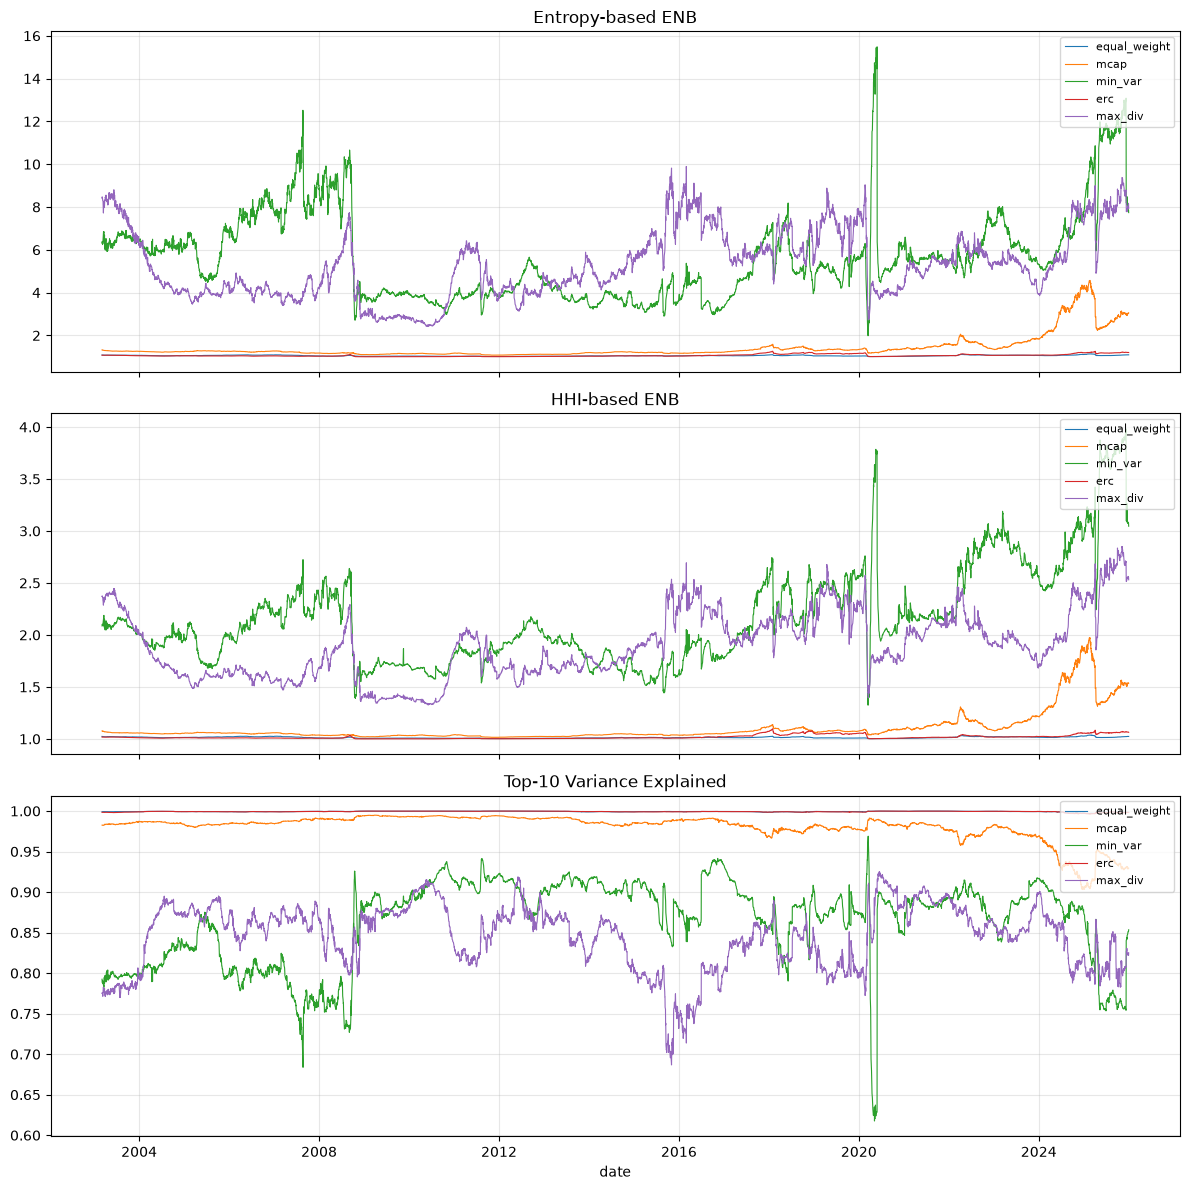

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

measure_cols = ["enb_entropy", "enb_hhi", "top_10_var_explained"]
titles = ["Entropy-based ENB", "HHI-based ENB", "Top-10 Variance Explained"]

for ax, col, title in zip(axes, measure_cols, titles):
    for name in PORTFOLIO_NAMES:
        sub = panel[panel["portfolio"] == name]
        ax.plot(sub["date"], sub[col], label=name, linewidth=0.8)
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()

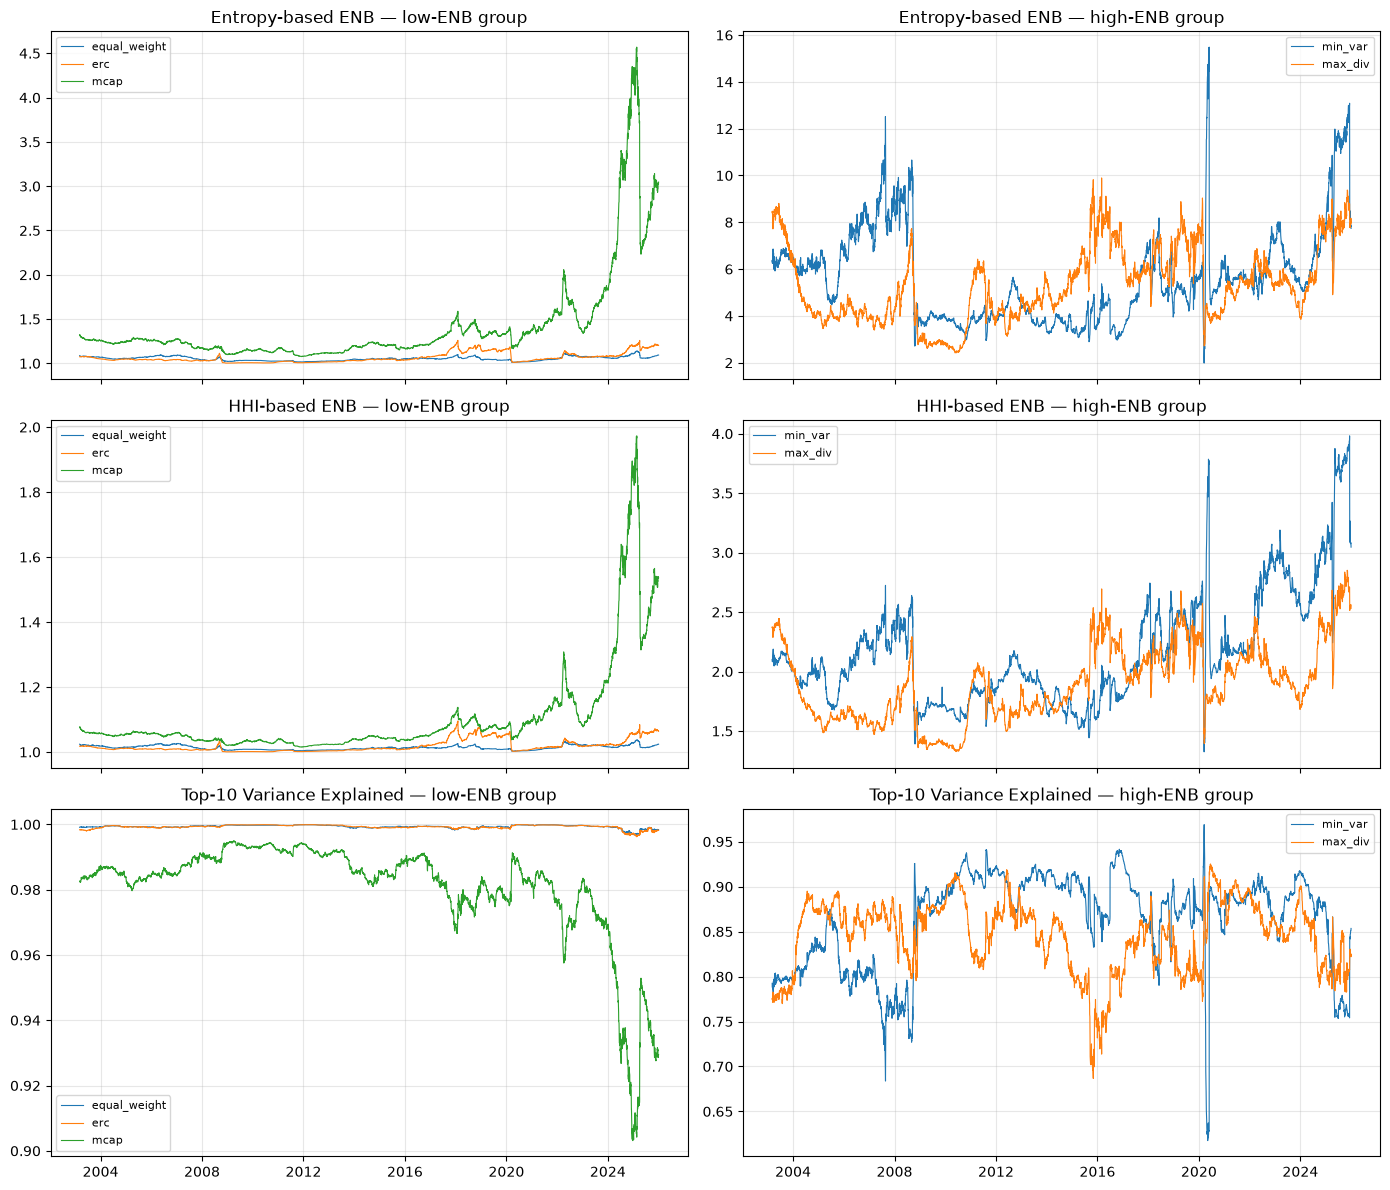

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

low_group = ["equal_weight", "erc", "mcap"]
high_group = ["min_var", "max_div"]

for row, col in enumerate(measure_cols):
    for name in low_group:
        sub = panel[panel["portfolio"] == name]
        axes[row, 0].plot(sub["date"], sub[col], label=name, linewidth=0.8)
    axes[row, 0].set_title(f"{titles[row]} — low-ENB group")
    axes[row, 0].legend(fontsize=8)
    axes[row, 0].grid(alpha=0.3)

    for name in high_group:
        sub = panel[panel["portfolio"] == name]
        axes[row, 1].plot(sub["date"], sub[col], label=name, linewidth=0.8)
    axes[row, 1].set_title(f"{titles[row]} — high-ENB group")
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Diversification of most diversified portfolios vs. absorption ratio

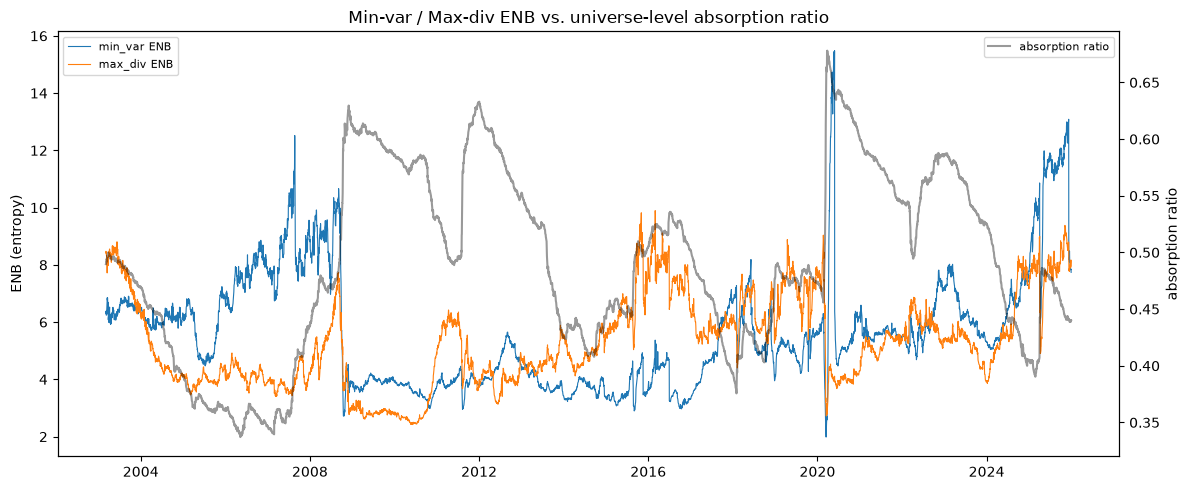

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 5))

for name in high_group:
    sub = panel[panel["portfolio"] == name]
    ax1.plot(sub["date"], sub["enb_entropy"], label=f"{name} ENB", linewidth=0.8)
ax1.set_ylabel("ENB (entropy)")
ax1.legend(loc="upper left", fontsize=8)

ax2 = ax1.twinx()
ar = panel[panel["portfolio"] == "min_var"][["date", "absorption_ratio"]]  # same across portfolios
ax2.plot(ar["date"], ar["absorption_ratio"], color="black", alpha=0.4, label="absorption ratio")
ax2.set_ylabel("absorption ratio")
ax2.legend(loc="upper right", fontsize=8)

plt.title("Min-var / Max-div ENB vs. universe-level absorption ratio")
plt.tight_layout()
plt.show()

In [28]:
n_holdings_full = []
for t in pca_results.keys():
    w = np.array(list(portfolios[t]["min_var"].values()))
    n_holdings_full.append({
        "date": t,
        "n_holdings": (w >= 1e-6).sum(),
        "top_eigval_share": pca_results[t]["explained_var_ratio"][0],
    })

nh_df = pd.DataFrame(n_holdings_full)
print(nh_df[["n_holdings", "top_eigval_share"]].corr())

# The extreme dates specifically
print("\nDates with most holdings (least concentrated):")
print(nh_df.nlargest(5, "n_holdings")[["date", "n_holdings", "top_eigval_share"]])

print("\nDates with fewest holdings (most concentrated):")
print(nh_df.nsmallest(5, "n_holdings")[["date", "n_holdings", "top_eigval_share"]])

                  n_holdings  top_eigval_share
n_holdings          1.000000          0.098037
top_eigval_share    0.098037          1.000000

Dates with most holdings (least concentrated):
           date  n_holdings  top_eigval_share
4341 2020-05-06         494          0.523489
4350 2020-05-19         494          0.520246
4351 2020-05-20         494          0.520573
2298 2012-03-22         492          0.521222
2305 2012-04-02         492          0.521585

Dates with fewest holdings (most concentrated):
           date  n_holdings  top_eigval_share
2189 2011-10-14          12          0.530088
2190 2011-10-17          12          0.530491
2191 2011-10-18          12          0.530732
2192 2011-10-19          12          0.530168
2193 2011-10-20          12          0.530201


# **5. Period analysis: Tariff Shock (2025)**

*Author: Bangjie. Uses the reusable helpers in `functions/period_analysis_functions.py`, which
Anthony / Bangjie / Chirag can reuse verbatim for the GFC, euro-zone, 2017-2018 and COVID windows by
changing only the `(start, end)` tuple.*

On **2 April 2025** ("Liberation Day") the U.S. administration announced a 10% baseline tariff on all
imports plus steep country-specific "reciprocal" tariffs on roughly 60 trading partners. Equities sold
off violently: the S&P 500 fell about **12% over the four sessions of 3-8 April**, its steepest such
move since 1950, and the VIX closed near **52** on 8 April. A 90-day pause announced on 9 April then
triggered a near-symmetric **V-shaped** recovery, with the index regaining most of the loss by mid-May.

This makes the tariff shock an unusually *clean* natural experiment for our diversification measures:
unlike the GFC (a slow-building solvency crisis) or the euro-zone episode (a grinding sovereign-risk
saga), it is an **exogenous, single-day policy shock with a fast, well-dated reversal**. If our
PCA-based diversification measures are picking up genuine market-structure stress, they should show a
sharp, brief compression around 2 April followed by a rapid normalisation — and the pattern should be
concentrated in the portfolios that actively bet *against* the dominant factor (min-variance,
max-diversification), not in the naive schemes (equal-weight, cap-weight, ERC) whose effective number
of bets is already close to one.

In [29]:
import functions.period_analysis_functions as period_functions

# Study windows (all defined centrally in the module so every period reuses the same code)
TARIFF_WINDOW   = ("2025-01-01", "2025-12-31")   # full episode + aftermath
CONTEXT_WINDOW  = ("2024-07-01", "2025-12-31")   # add ~6 calm months of context for the plots
ACUTE_WINDOW    = ("2025-04-01", "2025-05-31")   # the selloff + the initial rebound
CALM_2024       = ("2024-01-01", "2024-12-31")   # calm benchmark year
LIBERATION_DAY  = "2025-04-02"
ACUTE_SHADE     = ("2025-04-02", "2025-04-30")   # grey band = acute selloff

# Sanity check: confirm the diversification panel actually covers the episode.
cov = panel[panel["date"] >= "2025-01-01"]["date"]
print("2025 rows in panel:", len(cov))
print("Panel 2025 date range:", cov.min().date(), "to", cov.max().date())

2025 rows in panel: 1250
Panel 2025 date range: 2025-01-02 to 2025-12-31


## 5.1. Diversification through the episode

The three measures are plotted for all five portfolios from mid-2024 through end-2025. The dashed line
marks Liberation Day; the grey band is the acute selloff (2-30 April). Read the **min-variance** and
**max-diversification** lines: their entropy- and HHI-based effective number of bets (ENB) should dip
into the band and recover afterwards, while `top_10_var_explained` (an absorption-ratio-style measure,
so *higher = less* diversified) should spike.

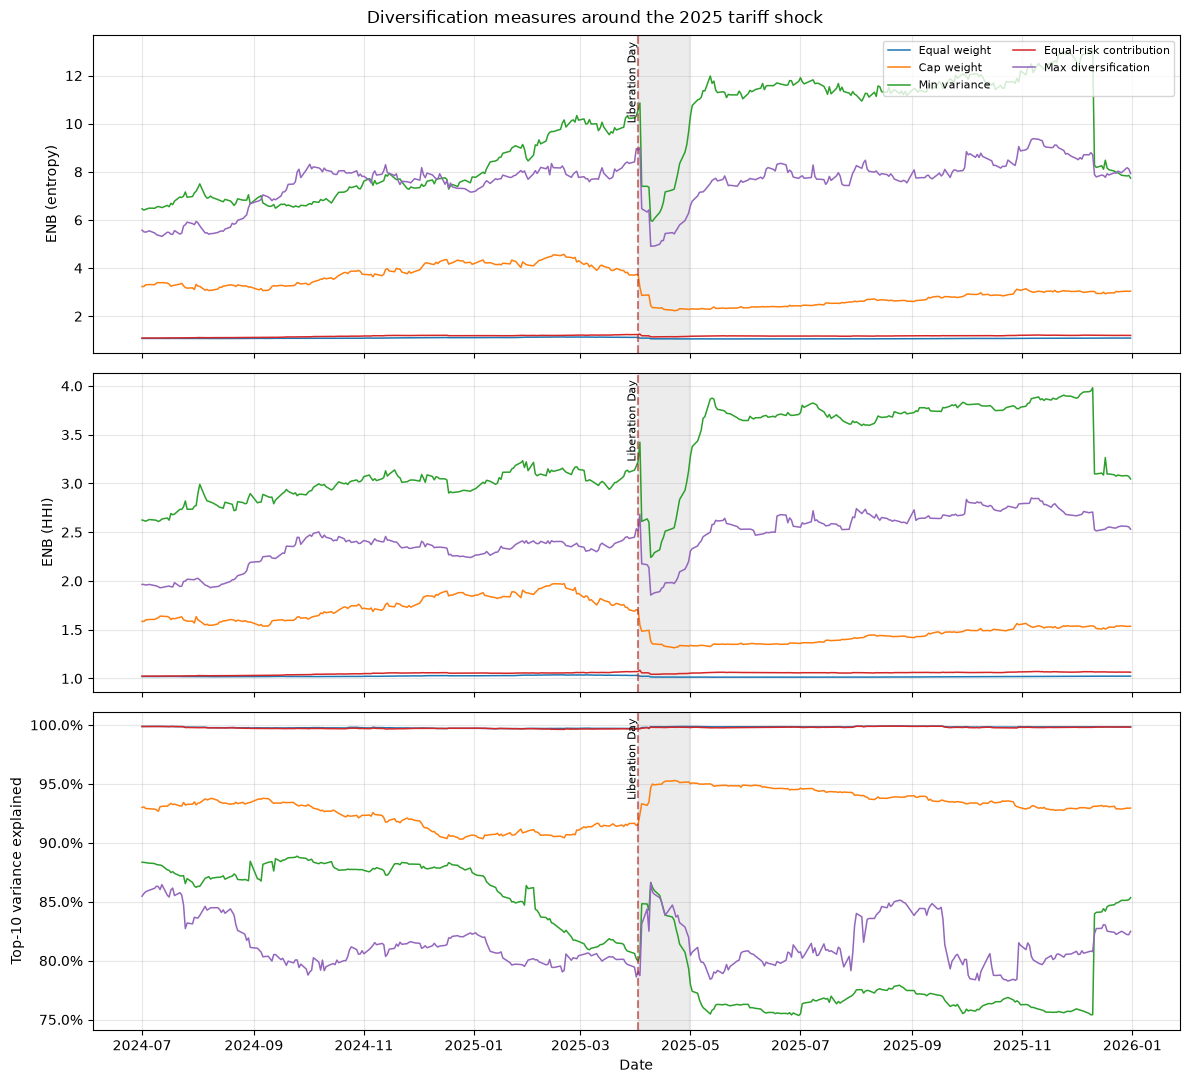

In [30]:
fig, axes = period_functions.plot_period_measures(
    panel,
    *CONTEXT_WINDOW,
    event_dates={"Liberation Day": pd.Timestamp(LIBERATION_DAY)},
    shade=ACUTE_SHADE,
    title="Diversification measures around the 2025 tariff shock",
)
plt.show()

## 5.2. Event study around Liberation Day

To compare the *speed and depth* of the reaction across portfolios on a common scale, we align each
measure to trading days relative to 2 April 2025 and index it to 100 at the shock date. The x-axis is
trading days from the event; 100 = the pre-shock diversification level. A V-shape confirms the
measure captured the shock and its reversal.

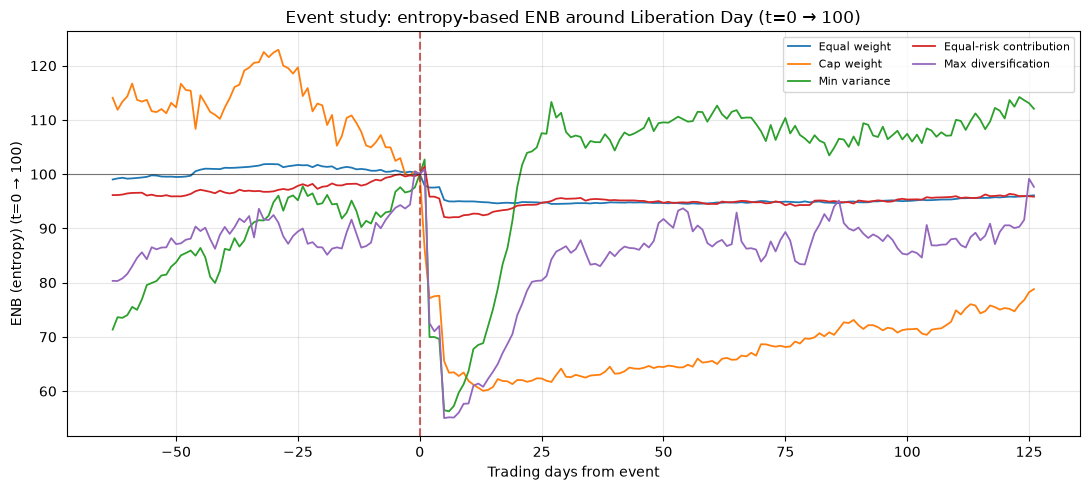

,equal_weight,mcap,min_var,erc,max_div
days_from_event,,,,,
-21,101.700000,113.000000,94.400000,97.300000,86.500000
-5,100.700000,102.400000,96.800000,99.900000,93.800000
0,100.000000,100.000000,100.000000,100.000000,100.000000
5,95.300000,65.500000,56.500000,92.100000,55.000000
21,94.900000,62.000000,101.700000,94.300000,76.100000
63,94.800000,66.100000,110.200000,94.800000,86.700000


In [31]:
# Normalised event study (t = 0 -> 100) for the entropy-based ENB.
fig, ax = period_functions.plot_event_study(
    panel, LIBERATION_DAY, measure="enb_entropy", pre=63, post=126, normalize=True,
    title="Event study: entropy-based ENB around Liberation Day (t=0 → 100)",
)
plt.show()

# Snapshot of the same event study at selected offsets (approx. -1m, -1w, shock, +1w, +1m, +3m).
es = period_functions.event_study(panel, LIBERATION_DAY, measure="enb_entropy",
                                  pre=63, post=126, normalize=True)
snapshot_offsets = [o for o in (-21, -5, 0, 5, 21, 63) if o in es.index]
display(es.loc[snapshot_offsets].round(1))

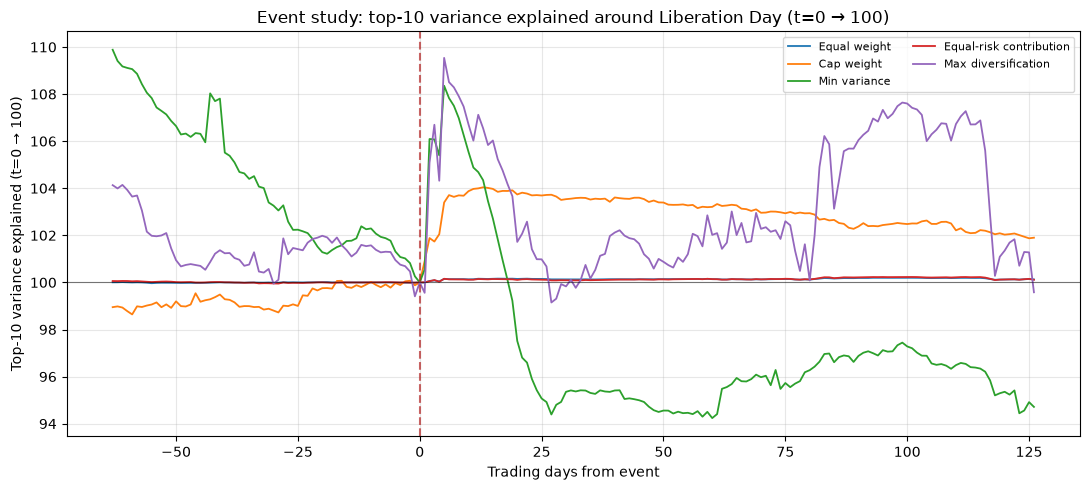

In [32]:
# Repeat the event study for the absorption-ratio-style measure (higher = less diversified).
fig, ax = period_functions.plot_event_study(
    panel, LIBERATION_DAY, measure="top_10_var_explained", pre=63, post=126, normalize=True,
    title="Event study: top-10 variance explained around Liberation Day (t=0 → 100)",
)
plt.show()

## 5.3. Summary statistics: calm 2024 vs. the tariff episode

Three side-by-side snapshots — calm 2024, the acute selloff (Apr-May 2025), and the full 2025 episode —
quantify how far each portfolio's diversification moved and how quickly it mean-reverted. The
peak-to-trough table then reports, for each portfolio, the largest drop in ENB inside the acute window
(a direct measure of how much diversification "collapsed"), and the date of the trough.

In [33]:
# Mean of each measure in three regimes, per portfolio.
regimes = {"Calm 2024": CALM_2024, "Acute Apr-May 2025": ACUTE_WINDOW, "Full 2025": TARIFF_WINDOW}

for measure in period_functions.MEASURE_COLS:
    print(f"\n=== mean {period_functions.MEASURE_LABELS[measure]} by regime ===")
    display(period_functions.compare_windows_table(panel, regimes, measure=measure, stat="mean").round(3))


=== mean ENB (entropy) by regime ===


,Calm 2024,Acute Apr-May 2025,Full 2025
Equal weight,1.074000,1.066000,1.084000
Cap weight,2.930000,2.448000,3.050000
Min variance,6.291000,9.539000,10.618000
Equal-risk contribution,1.117000,1.174000,1.192000
Max diversification,6.005000,6.745000,7.870000



=== mean ENB (HHI) by regime ===


,Calm 2024,Acute Apr-May 2025,Full 2025
Equal weight,1.019000,1.016000,1.021000
Cap weight,1.504000,1.375000,1.538000
Min variance,2.709000,3.176000,3.462000
Equal-risk contribution,1.032000,1.056000,1.060000
Max diversification,2.052000,2.307000,2.527000



=== mean Top-10 variance explained by regime ===


,Calm 2024,Acute Apr-May 2025,Full 2025
Equal weight,0.998000,0.998000,0.998000
Cap weight,0.940000,0.946000,0.932000
Min variance,0.890000,0.797000,0.791000
Equal-risk contribution,0.998000,0.998000,0.998000
Max diversification,0.843000,0.815000,0.811000


In [34]:
# Per-portfolio summary table for the full 2025 window.
display(period_functions.period_summary_table(panel, *TARIFF_WINDOW).round(3))

# Peak-to-trough collapse of the entropy-based ENB during the acute selloff.
print("\nPeak-to-trough of entropy ENB during the acute selloff:")
display(period_functions.drawdown_of_measure(panel, *ACUTE_WINDOW, measure="enb_entropy").round(3))

enb_entropy                              enb_hhi  \
                               mean      std      min       max     mean   
Equal weight               1.084000 0.027000 1.057000  1.139000 1.021000   
Cap weight                 3.050000 0.696000 2.232000  4.570000 1.538000   
Min variance              10.618000 1.606000 5.952000 13.086000 3.462000   
Equal-risk contribution    1.192000 0.020000 1.142000  1.259000 1.060000   
Max diversification        7.870000 0.802000 4.907000  9.379000 2.527000   

                                                   top_10_var_explained  \
                             std      min      max                 mean   
Equal weight            0.008000 1.013000 1.037000             0.998000   
Cap weight              0.192000 1.314000 1.973000             0.932000   
Min variance            0.400000 2.241000 3.981000             0.791000   
Equal-risk contribution 0.006000 1.043000 1.084000             0.998000   
Max diversification     0.207000 1.856000 2.851000             0.811000   

                                                    
                             std      min      max  
Equal weight            0.001000 0.997000 0.999000  
Cap weight              0.014000 0.903000 0.953000  
Min variance            0.037000 0.753000 0.873000  
Equal-risk contribution 0.001000 0.996000 0.999000  
Max diversification     0.019000 0.783000 0.866000


Peak-to-trough of entropy ENB during the acute selloff:


,window_start_level,peak_level,trough_level,trough_date,max_drawdown_pct,window_end_level
portfolio,,,,,,
Equal weight,1.122000,1.122000,1.057000,2025-05-13,-0.058000,1.060000
Cap weight,3.736000,3.736000,2.232000,2025-04-22,-0.402000,2.350000
Min variance,10.318000,10.862000,5.952000,2025-04-10,-0.452000,11.037000
Equal-risk contribution,1.237000,1.259000,1.142000,2025-04-10,-0.093000,1.182000
Max diversification,8.963000,8.999000,4.907000,2025-04-09,-0.455000,7.567000


In [35]:
# Cross-regime comparison against the other stress periods (does tariffs look different?).
print("Mean entropy-ENB by portfolio across all study windows:")
display(period_functions.compare_windows_table(panel, period_functions.PERIODS,
                                               measure="enb_entropy", stat="mean").round(3))

Mean entropy-ENB by portfolio across all study windows:


,GFC,Euro-zone,2017-2018,COVID,Tariffs
Equal weight,1.040000,1.025000,1.065000,1.019000,1.084000
Cap weight,1.153000,1.124000,1.368000,1.288000,3.050000
Min variance,7.055000,4.020000,5.398000,6.341000,10.618000
Equal-risk contribution,1.027000,1.012000,1.141000,1.035000,1.192000
Max diversification,4.292000,4.033000,6.052000,4.365000,7.870000


## 5.4. Absorption ratio and optimizer concentration

Finally we tie the portfolio-level result back to market structure. The universe-level **absorption
ratio** (share of variance in the top-10 PCs, identical across portfolios) should jump around the
shock — a mechanical driver of the ENB compression above. We also track how many names the
**min-variance** optimizer actually holds: under a correlation spike it tends to pile into a shrinking
set of low-beta names, which is exactly the loss of diversification the ENB measures are designed to
flag.

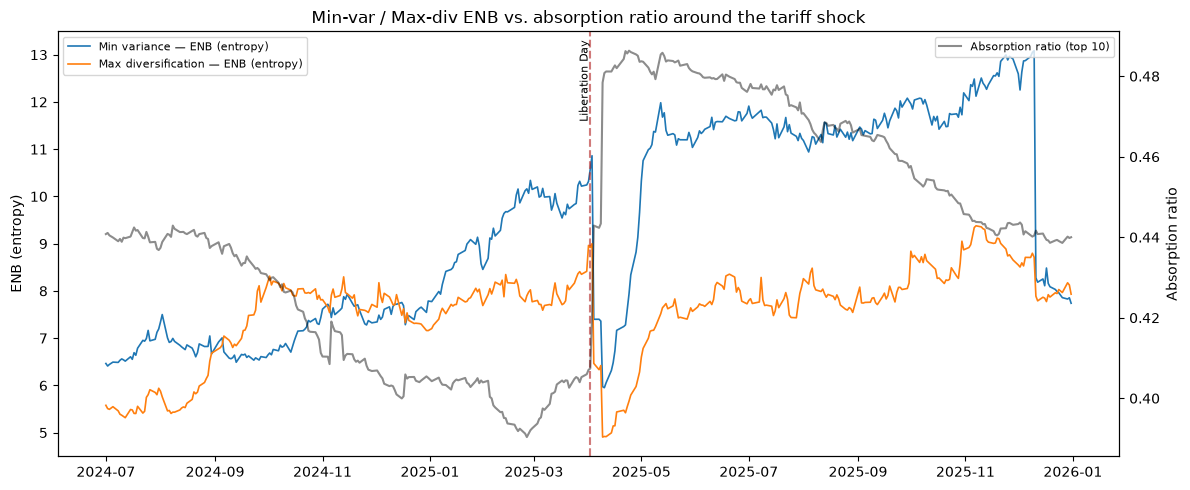

In [36]:
# High-ENB portfolios vs. the universe absorption ratio through the episode.
fig, (ax1, ax2) = period_functions.plot_absorption_with_measure(
    panel, *CONTEXT_WINDOW, measure="enb_entropy",
    portfolios_to_plot=("min_var", "max_div"),
    event_dates={"Liberation Day": pd.Timestamp(LIBERATION_DAY)},
    title="Min-var / Max-div ENB vs. absorption ratio around the tariff shock",
)
plt.show()

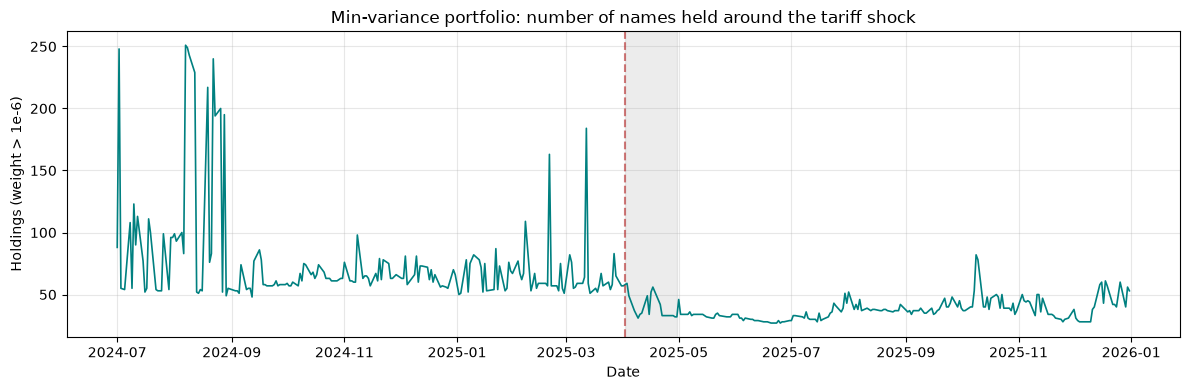

Fewest holdings: 27 on 2025-06-20
Holdings on/before Liberation Day: 58


In [37]:
# Number of names actually held by the min-variance portfolio through the episode.
mv_holdings = period_functions.holdings_concentration_series(portfolios, *CONTEXT_WINDOW, name="min_var")
if not mv_holdings.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(mv_holdings.index, mv_holdings.values, color="teal", linewidth=1.2)
    ax.axvline(pd.Timestamp(LIBERATION_DAY), color="firebrick", linestyle="--", alpha=0.6)
    ax.axvspan(pd.Timestamp(ACUTE_SHADE[0]), pd.Timestamp(ACUTE_SHADE[1]), color="grey", alpha=0.15)
    ax.set(title="Min-variance portfolio: number of names held around the tariff shock",
           xlabel="Date", ylabel="Holdings (weight > 1e-6)")
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    trough_date = mv_holdings.idxmin()
    print(f"Fewest holdings: {int(mv_holdings.min())} on {trough_date.date()}")
    print(f"Holdings on/before Liberation Day: "
          f"{int(mv_holdings.loc[:pd.Timestamp(LIBERATION_DAY)].iloc[-1])}")

## 5.5. Takeaways (tariff shock)

- **Who reacts.** The compression is concentrated in **min-variance** and **max-diversification**
  (entropy-ENB falling from ≈10.9 and ≈9.0 to a trough of ≈6.0 and ≈4.9, a **~45% peak-to-trough drop**
  for both), while **equal-weight** and **ERC** barely move (≈-6% and ≈-9%) - their effective number of
  bets is already ≈1, so there is little diversification left to lose. **Cap-weight** also falls sharply
  (≈-40%, 3.7 → 2.2), comparable in magnitude to the optimized portfolios rather than to equal-weight/ERC,
  since its higher baseline ENB (≈3) gives it real room to compress. This mirrors the full-sample ordering
  and confirms it is not an artefact of a single calm regime.

- **Shape.** The event study shows a sharp **V** for min-variance: the trough lands ≈5-6 trading days
  after Liberation Day, and the measure is not merely back near its pre-shock level but **above it
  (≈102) within ≈21 trading days**, settling into a sustained overshoot (~110-115) for the remainder of
  the year. Max-diversification's recovery is real but slower and weaker — still ≈76% of its pre-shock
  level at t+21 and ≈87% at t+63 — and cap-weight barely recovers at all, ending the six-month
  event-study window around ≈79% of where it started. The speed and completeness of recovery is not
  uniform across portfolios: min-variance overshoots, max-diversification partially recovers, and
  cap-weight does not.

- **Mechanism.** The ENB drop coincides with a spike in the **absorption ratio** (~0.44 → ~0.47 at the
  shock) and an immediate drop in the min-variance optimizer's holdings, from 58 names right before
  Liberation Day into the 30-50 range within the acute window — a market-wide correlation surge leaving
  fewer independent bets available, exactly as the ENB measures are designed to flag. That co-movement,
  however, holds only at the *onset*: holdings and ENB decouple during the recovery. Holdings stay
  persistently low for the rest of the year (settling in a ~30-50 name band, with a fresh minimum of 27
  not reached until June 20, over two months after the crash), even as min-variance's ENB fully recovers
  and overshoots its pre-shock level. A smaller, more selectively-chosen set of holdings achieved a
  *higher* effective number of independent bets than the larger, noisier pre-shock set — fewer names held
  did not mean less diversified once the optimizer had re-settled.

- **What is distinctive vs. other regimes.** Every portfolio's mean entropy-ENB over full-2025 is the
  highest of the five study windows (min-variance: 10.6 vs. 7.1 / 4.0 / 5.4 / 6.3 for GFC / Euro-zone /
  2017-18 / COVID). This is best read as a window-composition effect rather than evidence that the
  tariff shock itself improved diversification: the acute episode was brief, and the rest of 2025 was on
  average calmer than 2024, while the other study windows span months to years of more sustained stress.
  Cap-weight is the standout distinctive result: its ENB in 2025 (3.05) is more than double its level in
  any other period studied (next-highest 1.37, in 2017-18) — a materially different ranking than
  elsewhere, where cap-weight sits close to equal-weight. A like-for-like comparison of collapse depth and
  recovery speed against COVID would need the same drawdown/event-study calls run on a COVID-specific
  window before it can be stated with the same precision as the tariff numbers above.